In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('house_prices.csv')
data.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
data.shape


(187531, 21)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [5]:
missing_sum=data.isnull().sum()
missing_sum=missing_sum[missing_sum>0]
missing_percentage=missing_sum/len(data)*100
missing_values =pd.DataFrame()
missing_values['missing_sum']=missing_sum
missing_values['missing_percentage']=missing_percentage
missing_values=missing_values.sort_values(by='missing_sum', ascending=False)
missing_values


,missing_sum,missing_percentage
Plot Area,187531,100.000000
Dimensions,187531,100.000000
Society,109678,58.485264
Super Area,107685,57.422506
Car Parking,103357,55.114621
overlooking,81436,43.425354
Carpet Area,80673,43.018488
facing,70233,37.451408
Ownership,65517,34.936624
Balcony,48935,26.094352


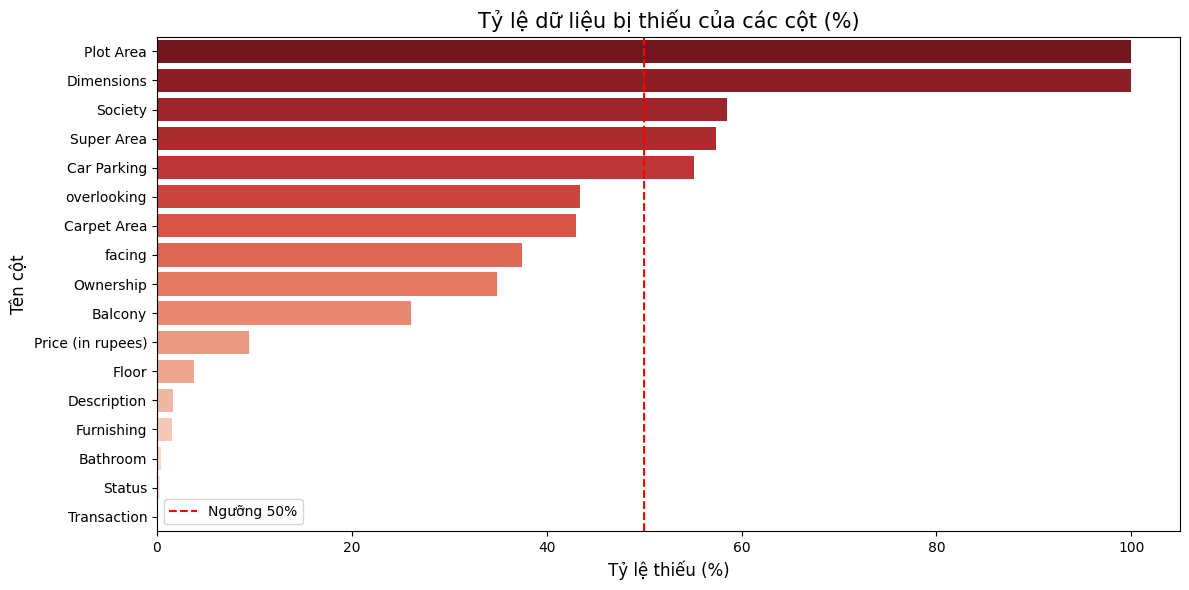

In [6]:


plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values['missing_percentage'], y=missing_values.index, palette='Reds_r')
plt.title('Tỷ lệ dữ liệu bị thiếu của các cột (%)', fontsize=15)
plt.xlabel('Tỷ lệ thiếu (%)', fontsize=12)
plt.ylabel('Tên cột', fontsize=12)
plt.axvline(x=50, color='red', linestyle='--', label='Ngưỡng 50%')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# EDA trước khi cleaning: phân phối biến phân loại và biến liên tục

eda_data = data.copy()

# Loại các cột text dài khỏi phân tích categorical
long_text_cols = []
for col in eda_data.select_dtypes(include='object').columns:
    avg_len = eda_data[col].dropna().astype(str).str.len().mean()
    if pd.notna(avg_len) and avg_len > 40:
        long_text_cols.append(col)

# Tách giá trị và đơn vị từ các cột có chuỗi lẫn đơn vị
amount_parts = eda_data['Amount(in rupees)'].astype(str).str.extract(r'(?P<amount_value>[0-9]*\.?[0-9]+)\s*(?P<amount_unit>[A-Za-z]+)?')
amount_parts['amount_value'] = pd.to_numeric(amount_parts['amount_value'], errors='coerce')
amount_parts['amount_unit'] = amount_parts['amount_unit'].str.upper().fillna('UNKNOWN')

carpet_parts = eda_data['Carpet Area'].astype(str).str.extract(r'(?P<carpet_value>[0-9]*\.?[0-9]+)\s*(?P<carpet_unit>.*)')
carpet_parts['carpet_value'] = pd.to_numeric(carpet_parts['carpet_value'], errors='coerce')
carpet_parts['carpet_unit'] = carpet_parts['carpet_unit'].str.strip().str.lower().replace('', np.nan).fillna('unknown')

eda_data = pd.concat([eda_data, amount_parts, carpet_parts], axis=1)

# Biến phân loại: bỏ text dài và bỏ các cột đã tách đơn vị để xử lý riêng
categorical_cols = [
    col for col in eda_data.select_dtypes(include='object').columns
    if col not in long_text_cols + ['Amount(in rupees)', 'Carpet Area']
]

# Biến liên tục: gồm numeric gốc và numeric tách ra từ cột có đơn vị
continuous_cols = []
for col in ['Price (in rupees)', 'amount_value', 'carpet_value']:
    if col in eda_data.columns and eda_data[col].notna().sum() > 0:
        continuous_cols.append(col)

Categorical columns duoc ve: ['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Ownership', 'Floor', 'Bathroom', 'Balcony', 'Car Parking']


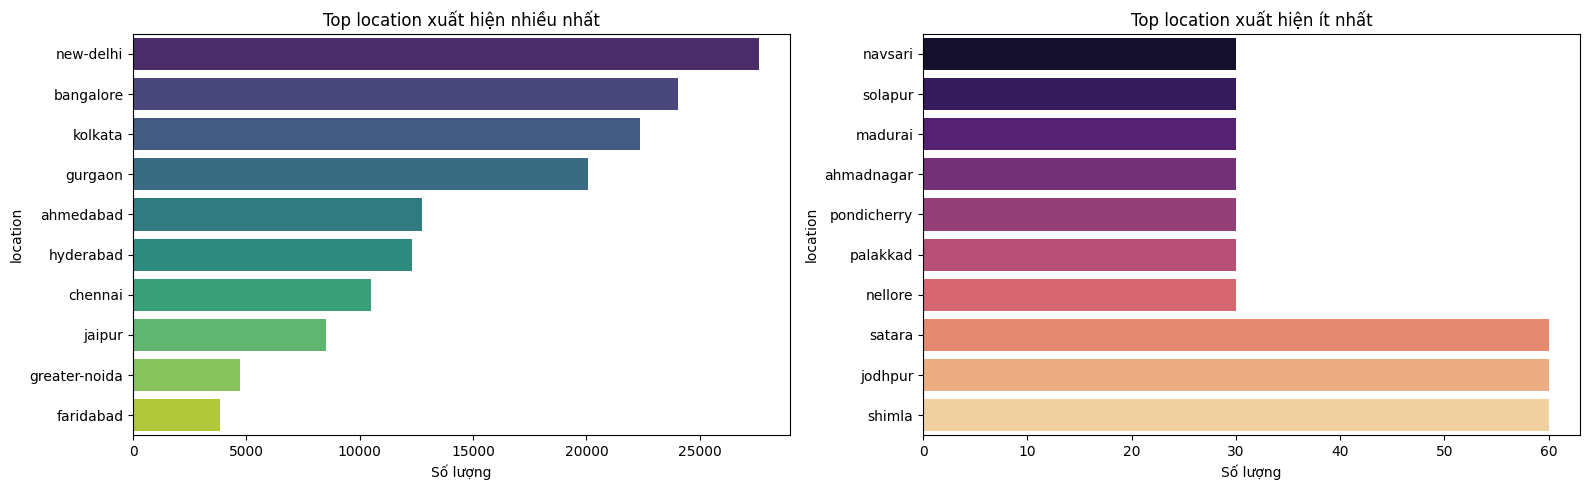

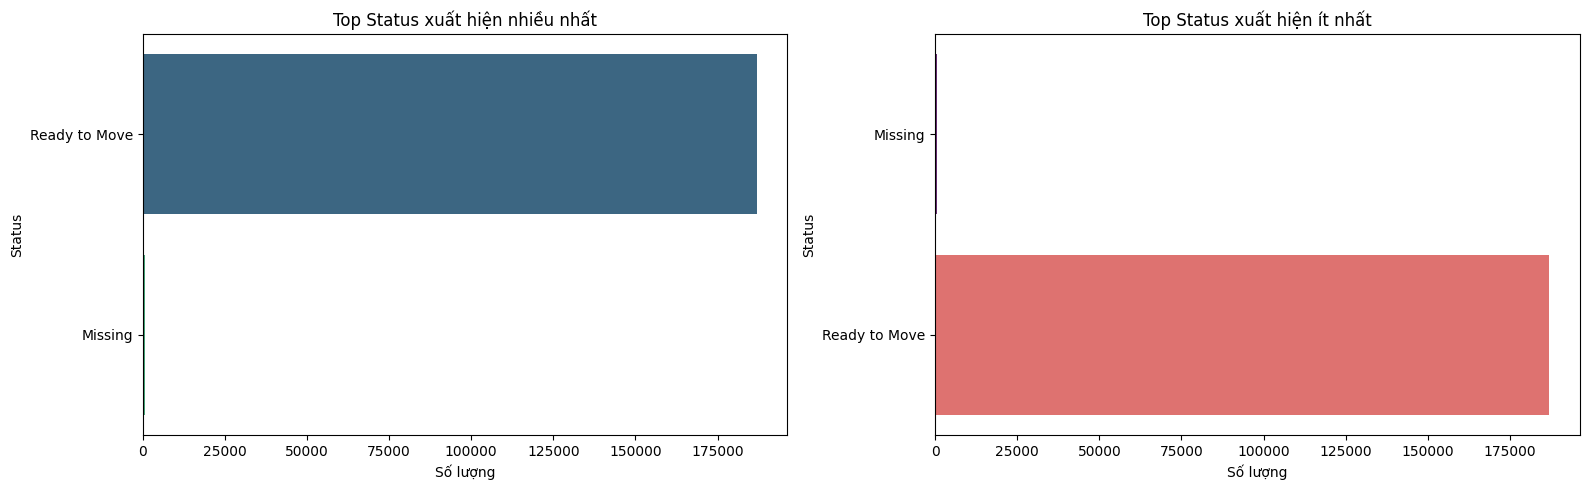

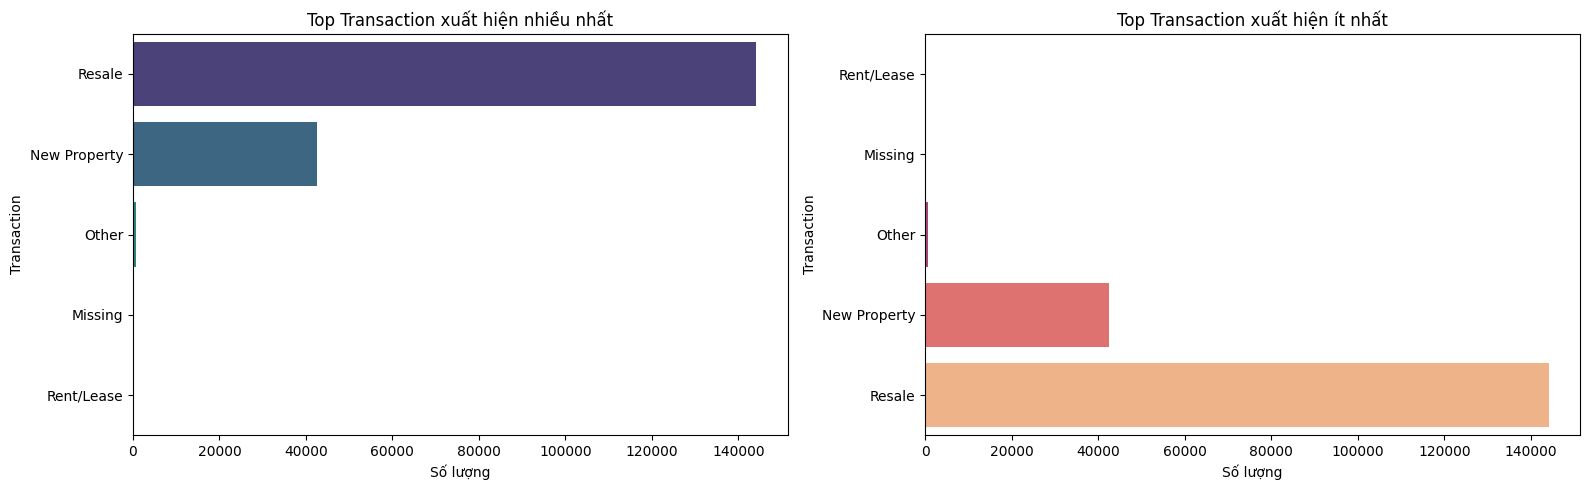

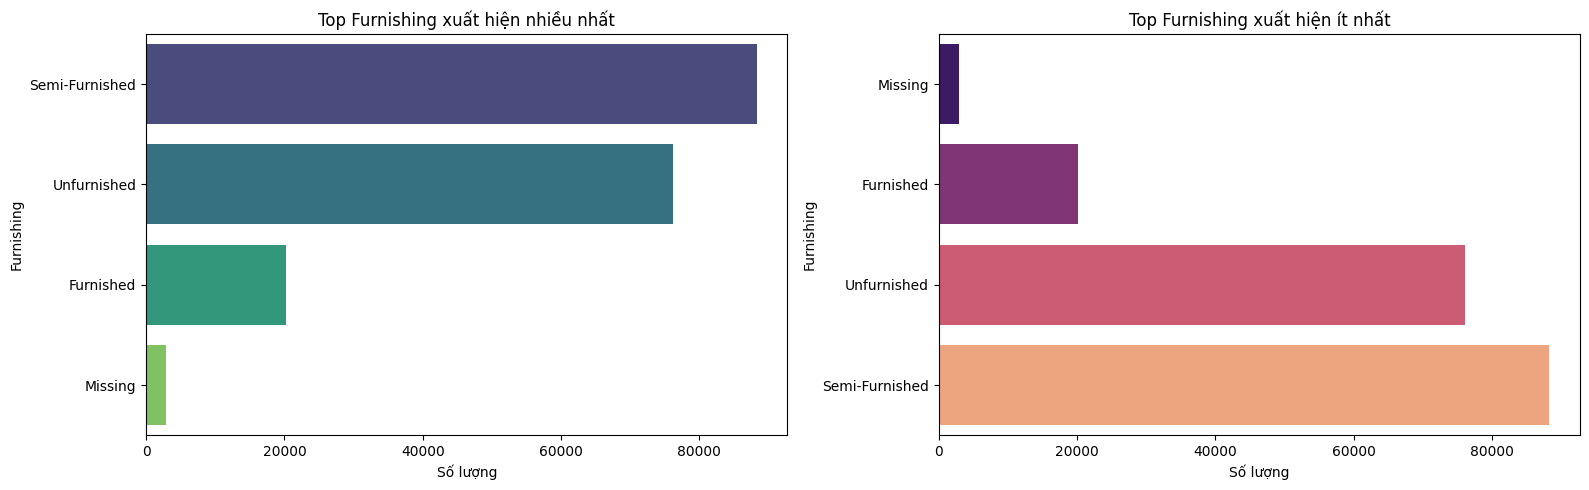

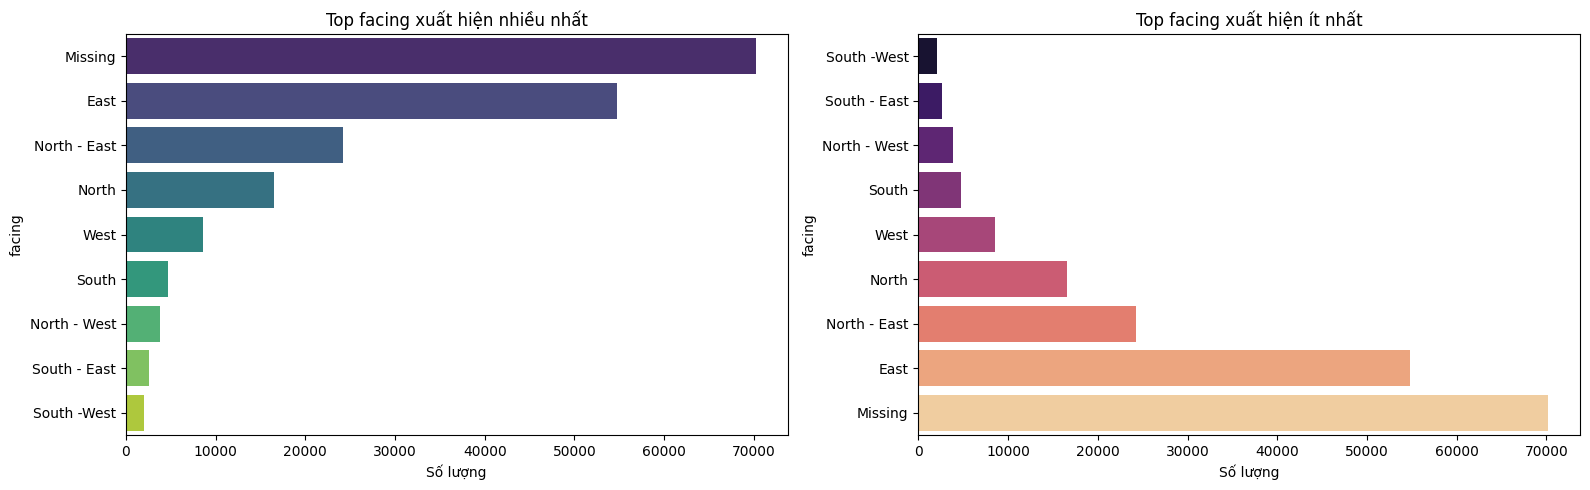

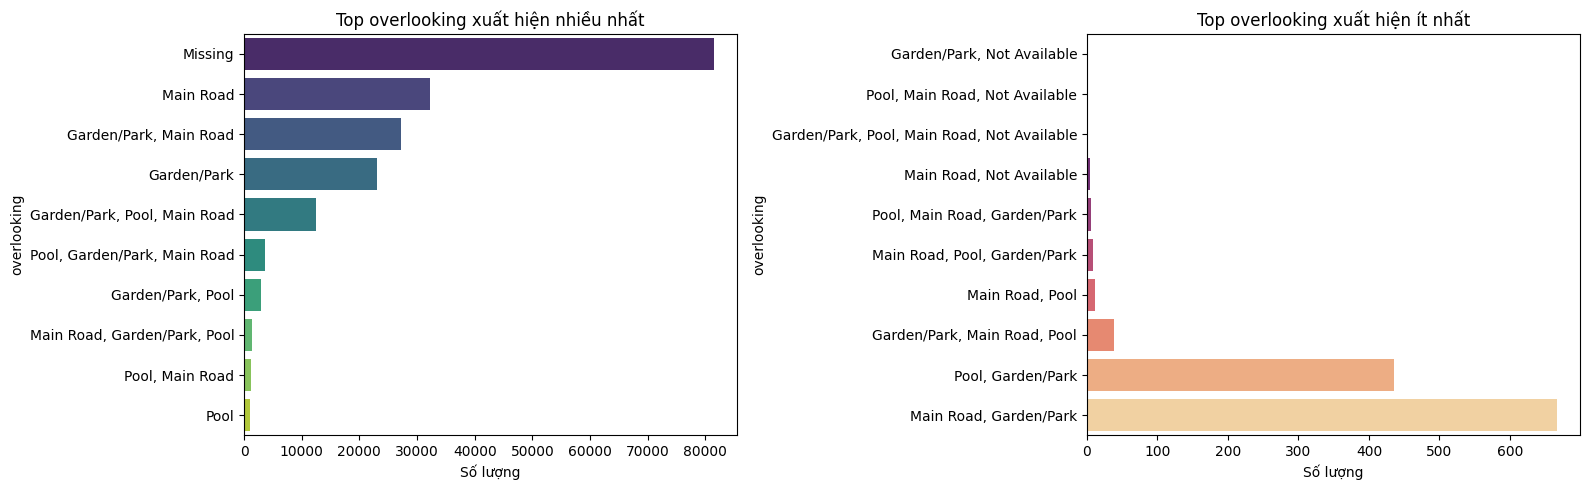

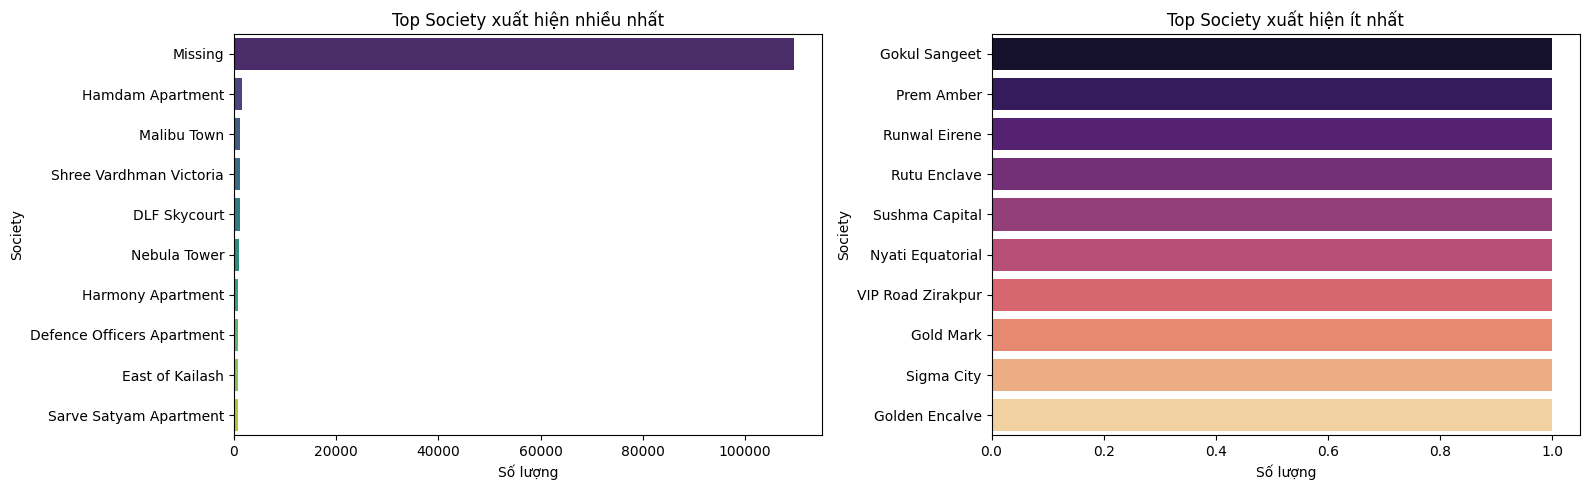

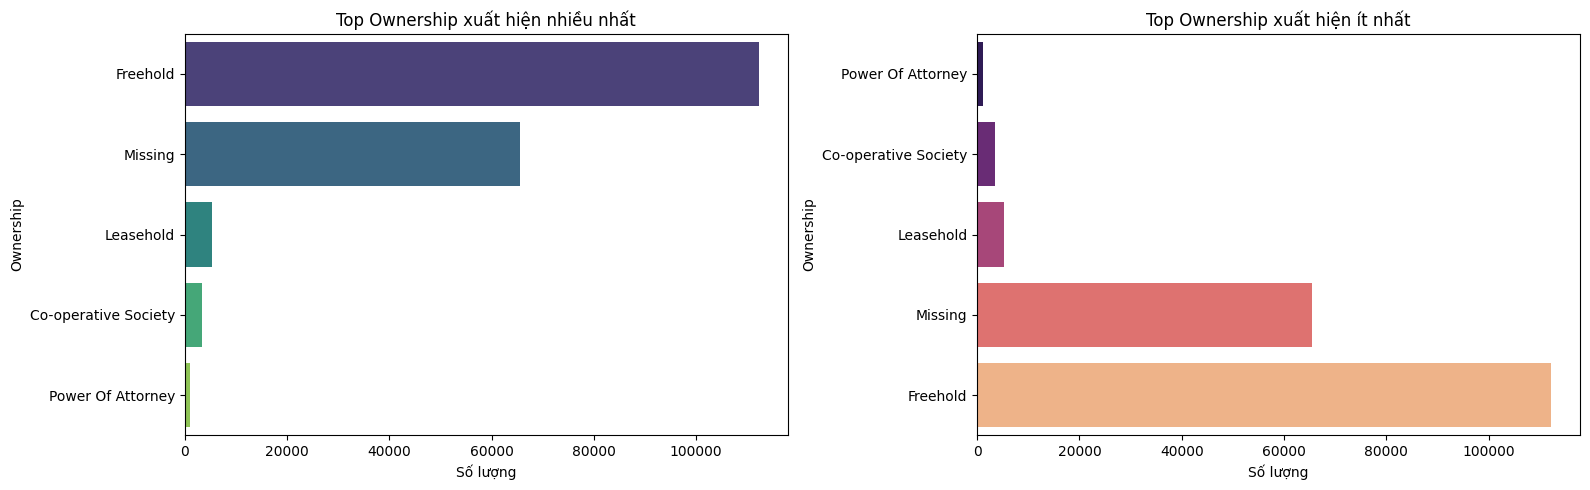

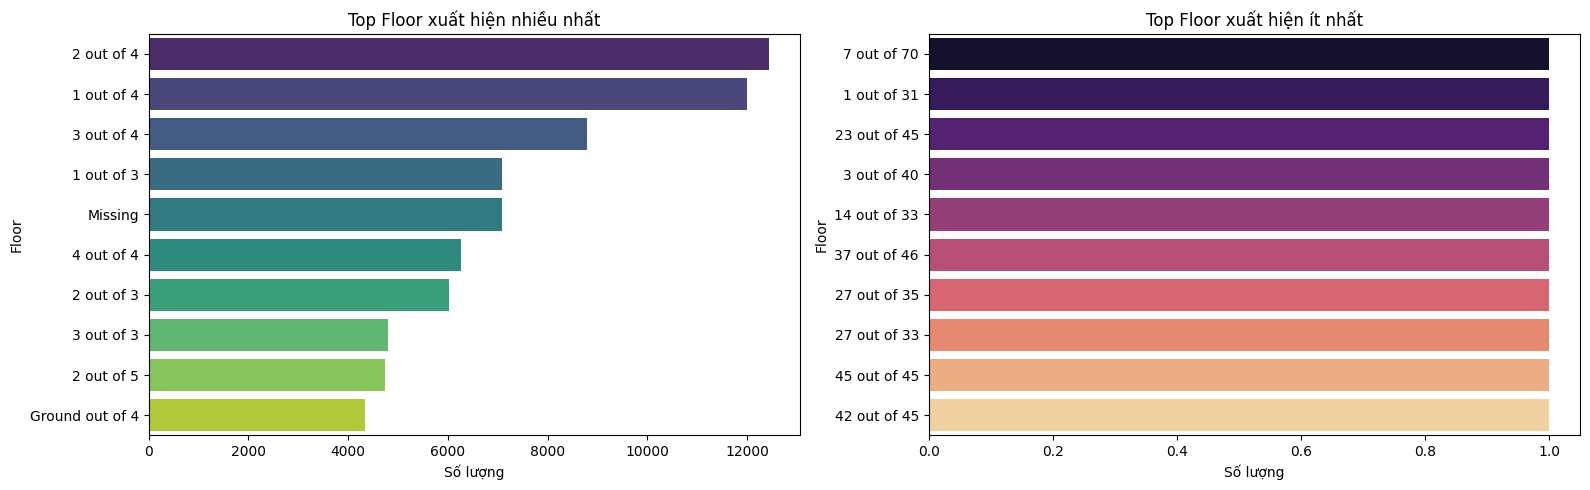

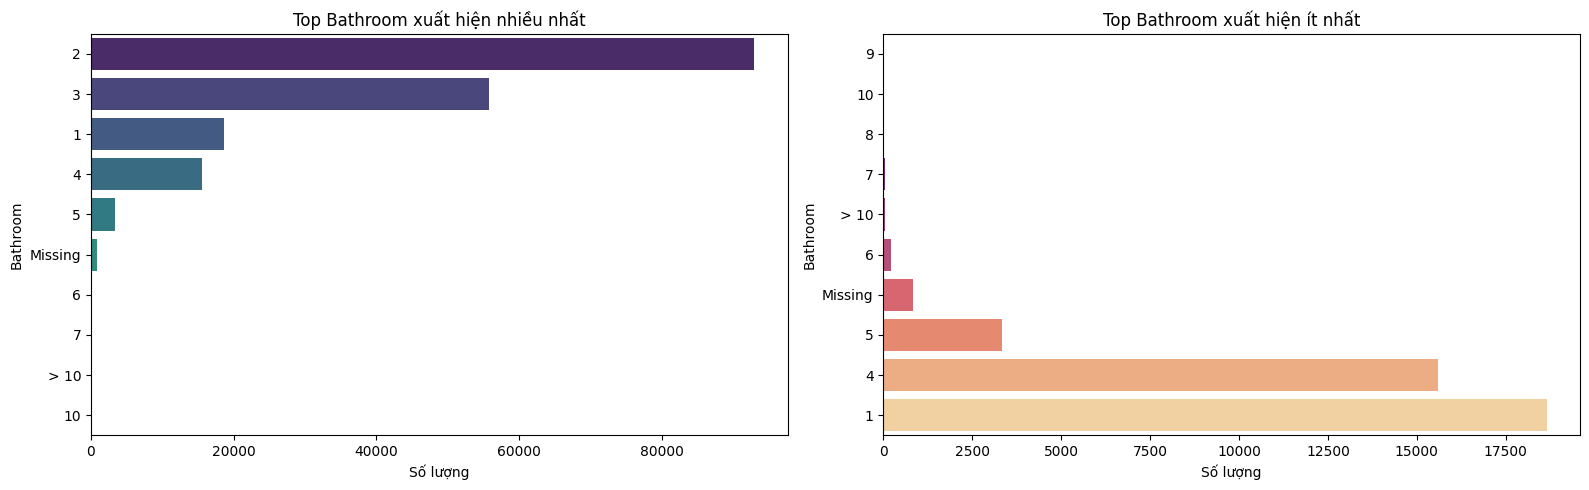

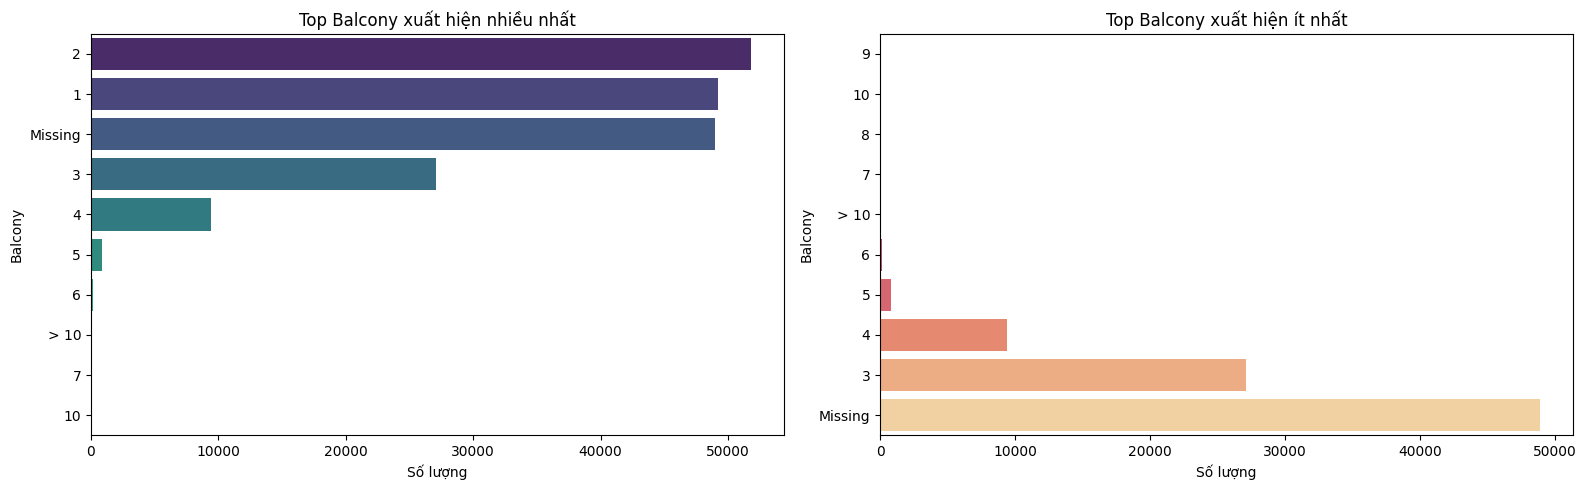

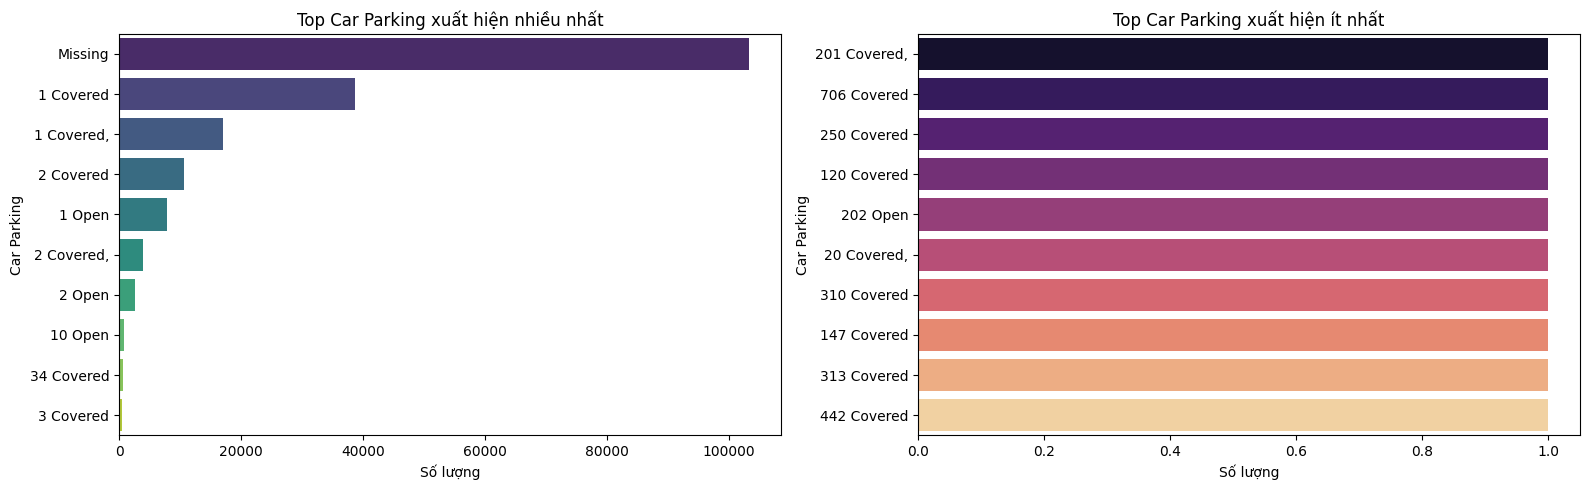

In [8]:
# Categorical distribution: top xuat hien nhieu nhat va it nhat

eda_data = data.copy()

categorical_cols = [
    'location', 'Status', 'Transaction', 'Furnishing', 'facing',
    'overlooking', 'Society', 'Ownership', 'Floor', 'Bathroom',
    'Balcony', 'Car Parking'
]

categorical_cols = [col for col in categorical_cols if col in eda_data.columns]
print('Categorical columns duoc ve:', categorical_cols)

for col in categorical_cols:
    value_counts = eda_data[col].fillna('Missing').astype(str).value_counts()
    top_most = value_counts.head(10)
    top_least = value_counts.sort_values(ascending=True).head(10)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(x=top_most.values, y=top_most.index, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Top {col} xuất hiện nhiều nhất')
    axes[0].set_xlabel('Số lượng')
    axes[0].set_ylabel(col)

    sns.barplot(x=top_least.values, y=top_least.index, ax=axes[1], palette='magma')
    axes[1].set_title(f'Top {col} xuất hiện ít nhất')
    axes[1].set_xlabel('Số lượng')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

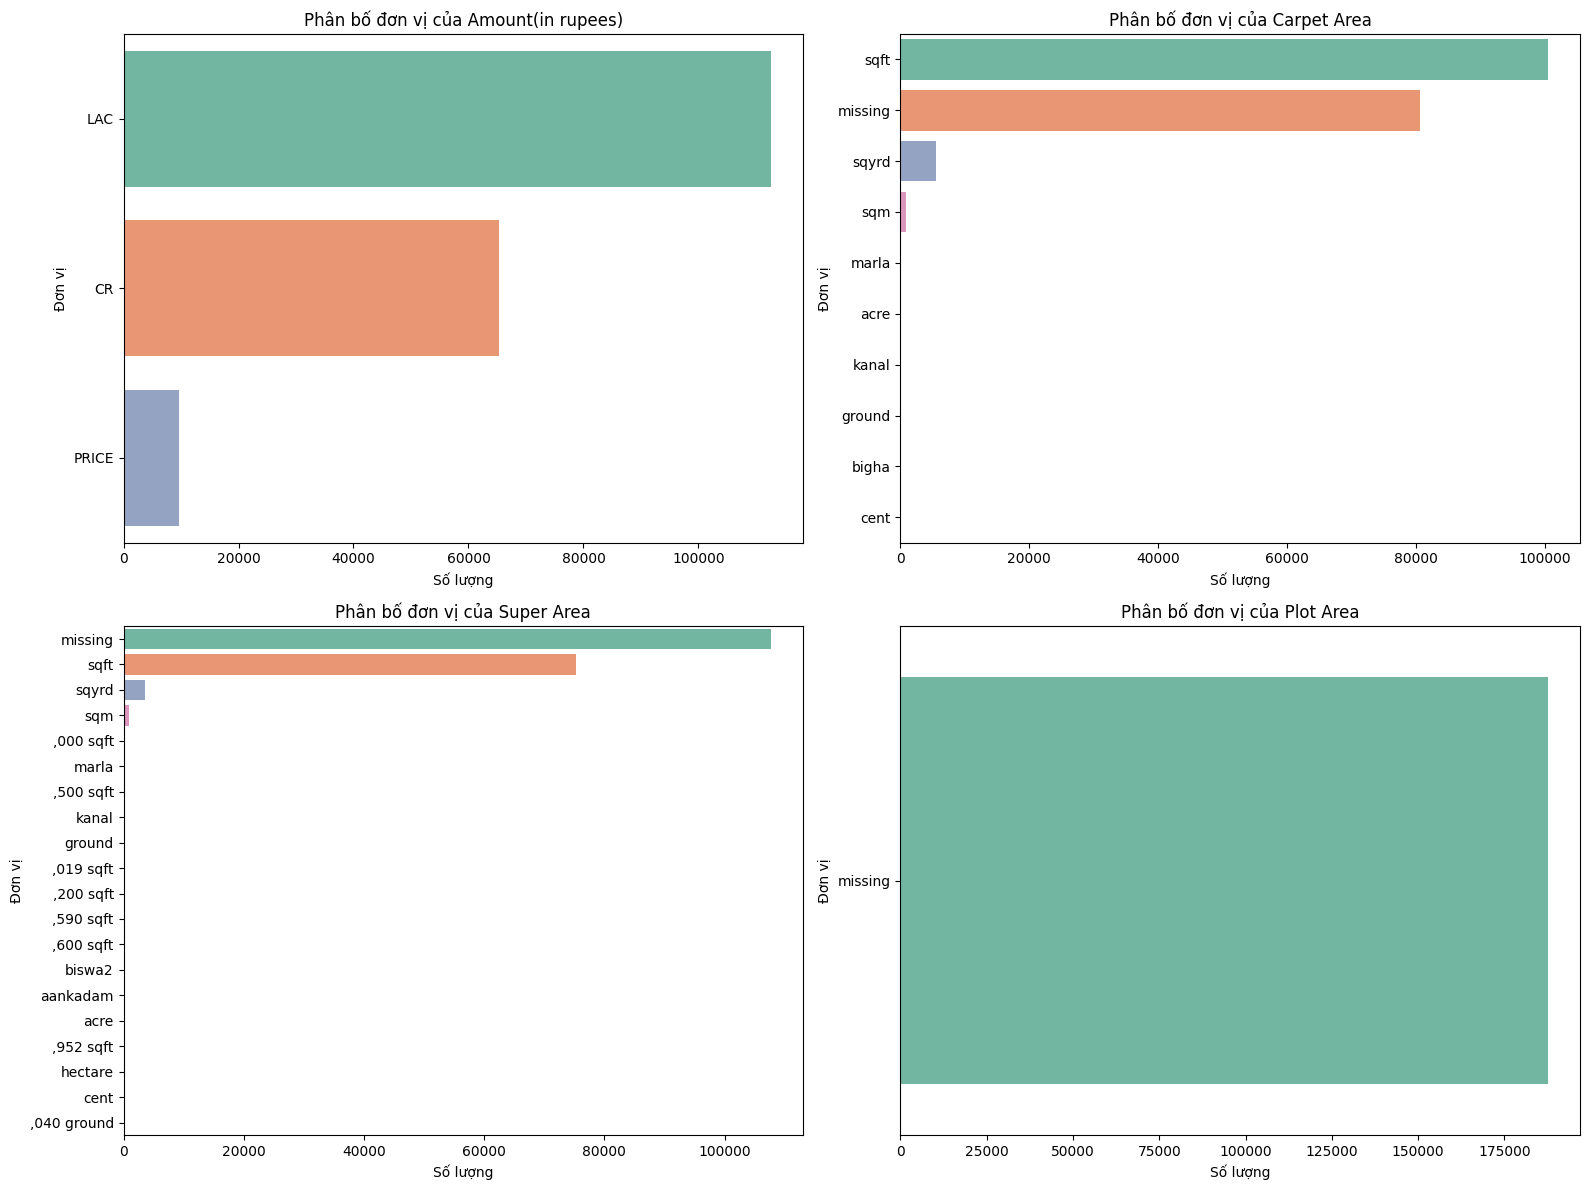

In [9]:
# Phan bo don vi cua Carpet Area, Amount(in rupees), Super Area, Plot Area

unit_data = data.copy()
def extract_amount_unit(x):
    if pd.isna(x):
        return 'missing'
    match = re.search(r'([A-Za-z]+)\s*$', str(x).strip())
    return match.group(1).upper() if match else 'unknown'


def extract_area_unit(x):
    if pd.isna(x):
        return 'missing'
    text = str(x).strip().lower()
    match = re.match(r'[0-9]*\.?[0-9]+\s*(.*)', text)
    if not match:
        return 'unknown'
    unit = match.group(1).strip()
    return unit if unit else 'unknown'


unit_features = {
    'Amount(in rupees)': unit_data['Amount(in rupees)'].apply(extract_amount_unit),
    'Carpet Area': unit_data['Carpet Area'].apply(extract_area_unit),
    'Super Area': unit_data['Super Area'].apply(extract_area_unit),
    'Plot Area': unit_data['Plot Area'].apply(extract_area_unit),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (col, series) in zip(axes, unit_features.items()):
    counts = series.value_counts(dropna=False)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='Set2')
    ax.set_title(f'Phân bố đơn vị của {col}')
    ax.set_xlabel('Số lượng')
    ax.set_ylabel('Đơn vị')

plt.tight_layout()
plt.show()



Data cleaning

In [10]:
data = data.drop(columns=['Dimensions', 'Plot Area','Society','Super Area','Car Parking'])

In [11]:
data['overlooking'] = data['overlooking'].fillna('Unknown')

In [12]:
data['Carpet Area']

0          500 sqft
1          473 sqft
2          779 sqft
3          530 sqft
4          635 sqft
            ...    
187526          NaN
187527          NaN
187528    1250 sqft
187529          NaN
187530          NaN
Name: Carpet Area, Length: 187531, dtype: object

In [13]:
def clean_area(x):
    if pd.isna(x):
        return np.nan
    x=str(x).lower()
    match = re.match(r'([0-9.]+)\s*(.*)',x)
    if match:
        value = float(match.group(1))
        unit = match.group(2).strip()
        if 'sqm' in unit or 'sq.m.' in unit:
            return value * 10.7639
        elif 'sqyrd' in unit or 'sq.yd' in unit or 'sqyd' in unit:
            return value * 9.0
        elif 'cent' in unit:
            return value * 435.6
        elif 'acre' in unit:
            return value * 43560.0
        elif 'guntha' in unit:
            return value * 1089.0
        elif 'bigha' in unit:
            return value * 27000.0
        elif 'hectare' in unit:
            return value * 107639.0
        return value 
    return np.nan 

In [14]:
data['Carpet Area'] = data['Carpet Area'].apply(clean_area)


In [15]:
data['Carpet Area'] = data['Carpet Area'].fillna(data['Carpet Area'].median())

In [16]:
data['Carpet Area'].describe()

count    1.875310e+05
mean     1.757080e+03
std      1.811317e+05
min      1.000000e+00
25%      1.000000e+03
50%      1.064000e+03
75%      1.197000e+03
max      6.534000e+07
Name: Carpet Area, dtype: float64

In [17]:
data['Carpet Area'].isnull().sum()

np.int64(0)

In [18]:
data['Carpet Area']

0          500.0
1          473.0
2          779.0
3          530.0
4          635.0
           ...  
187526    1064.0
187527    1064.0
187528    1250.0
187529    1064.0
187530    1064.0
Name: Carpet Area, Length: 187531, dtype: float64

In [19]:
data['facing'].value_counts()

facing
East            54741
North - East    24220
North           16533
West             8574
South            4694
North - West     3843
South - East     2622
South -West      2071
Name: count, dtype: int64

In [20]:
data['facing'] = data['facing'].fillna('Unknown')
data['facing'].value_counts()

facing
Unknown         70233
East            54741
North - East    24220
North           16533
West             8574
South            4694
North - West     3843
South - East     2622
South -West      2071
Name: count, dtype: int64

In [21]:
data['Ownership'].value_counts()

Ownership
Freehold                112229
Leasehold                 5285
Co-operative Society      3431
Power Of Attorney         1069
Name: count, dtype: int64

In [22]:
data['Ownership'] = data['Ownership'].fillna('Unknown')
data['Ownership'].value_counts()

Ownership
Freehold                112229
Unknown                  65517
Leasehold                 5285
Co-operative Society      3431
Power Of Attorney         1069
Name: count, dtype: int64

In [23]:
# Chuyển đổi "Amount(in rupees)" từ chuỗi sang số và quy đổi sang USD
def parse_amount(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    match = re.match(r'([0-9.]+)\s*(Lac|Cr)', x, re.IGNORECASE)
    if match:
        val = float(match.group(1))
        unit = match.group(2).lower()
        rupees = 0
        if unit == 'lac':
            rupees = val * 100000
        elif unit == 'cr':
            rupees = val * 10000000
        
        # Giả sử tỷ giá 1 USD ≈ 83 INR
        usd_value = rupees / 83.0
        return usd_value
    return np.nan

data['Price_total'] = data['Amount(in rupees)'].apply(parse_amount)

# Kiểm tra kết quả
print("Null trong Price_total:", data['Price_total'].isnull().sum())
print("\nMẫu dữ liệu (Quy đổi sang USD):")
print(data[['Amount(in rupees)', 'Price_total']].head(10))

Null trong Price_total: 9684

Mẫu dữ liệu (Quy đổi sang USD):
  Amount(in rupees)    Price_total
0           42 Lac    50602.409639
1           98 Lac   118072.289157
2          1.40 Cr   168674.698795
3           25 Lac    30120.481928
4          1.60 Cr   192771.084337
5           45 Lac    54216.867470
6         16.5 Lac    19879.518072
7           60 Lac    72289.156627
8           60 Lac    72289.156627
9          1.60 Cr   192771.084337


In [24]:
data.drop(columns='Amount(in rupees)',inplace=True)

In [25]:
data['Price_total']

0          50602.409639
1         118072.289157
2         168674.698795
3          30120.481928
4         192771.084337
              ...      
187526     75903.614458
187527     66265.060241
187528     91566.265060
187529     36144.578313
187530    142168.674699
Name: Price_total, Length: 187531, dtype: float64

In [26]:
# Tách cột Floor chỉ lấy floor_number
def parse_floor(x):
    if pd.isna(x):
        return np.nan
    match = re.match(r'(\d+)\s*out\s*of\s*(\d+)', str(x))
    if match:
        return int(match.group(1))
    return np.nan

data['floor_number'] = data['Floor'].apply(parse_floor)

# Chuyển Bathroom và Balcony sang số, "> 10" → 11
def parse_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if '>' in x:
        return 11
    try:
        return int(float(x))
    except ValueError:
        return np.nan

data['Bathroom'] = data['Bathroom'].apply(parse_count)
data['Balcony'] = data['Balcony'].apply(parse_count)

# Điền null bằng median
data['floor_number'] = data['floor_number'].fillna(data['floor_number'].median())
data['Bathroom'] = data['Bathroom'].fillna(data['Bathroom'].median())
data['Balcony'] = data['Balcony'].fillna(data['Balcony'].median())

print("Kiểm tra null còn lại:")
print(data[['floor_number', 'Bathroom', 'Balcony']].isnull().sum())

Kiểm tra null còn lại:
floor_number    0
Bathroom        0
Balcony         0
dtype: int64


In [27]:
# Điền null cho các cột phân loại còn lại
data['Status'] = data['Status'].fillna('Ready to Move')
data['Transaction'] = data['Transaction'].fillna(data['Transaction'].mode()[0])
data['Furnishing'] = data['Furnishing'].fillna(data['Furnishing'].mode()[0])

# Trích xuất số phòng (BHK) từ Title
def extract_bhk(title):
    if pd.isna(title):
        return np.nan
    match = re.search(r'(\d+)\s*BHK', str(title), re.IGNORECASE)
    if match:
        return int(match.group(1))
    return np.nan

data['BHK'] = data['Title'].apply(extract_bhk)
data['BHK'] = data['BHK'].fillna(data['BHK'].median())

# Xóa cột không cần thiết cho mô hình
data = data.drop(columns=['Index', 'Title', 'Description',
                           'Price (in rupees)', 'Floor'])

# Xóa dòng không có giá (target)
print(f"Số dòng trước khi xóa null target: {len(data)}")
data = data.dropna(subset=['Price_total'])
print(f"Số dòng sau khi xóa null target: {len(data)}")

# Kiểm tra tổng quan null
null_counts = data.isnull().sum()
print(f"\nTổng null còn lại: {null_counts.sum()}")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Không còn giá trị null nào!")

# Đảm bảo không còn null
assert data.isnull().sum().sum() == 0, "Vẫn còn giá trị null!"
print(f"\nShape cuối cùng: {data.shape}")
data.head()

Số dòng trước khi xóa null target: 187531
Số dòng sau khi xóa null target: 177847

Tổng null còn lại: 0
Không còn giá trị null nào!

Shape cuối cùng: (177847, 13)


,location,Carpet Area,Status,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership,Price_total,floor_number,BHK
0,thane,500.0,Ready to Move,Resale,Unfurnished,Unknown,Unknown,1.0,2.0,Unknown,50602.409639,10.0,1.0
1,thane,473.0,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,2.0,2.0,Freehold,118072.289157,3.0,2.0
2,thane,779.0,Ready to Move,Resale,Unfurnished,East,Garden/Park,2.0,2.0,Freehold,168674.698795,10.0,2.0
3,thane,530.0,Ready to Move,Resale,Unfurnished,Unknown,Unknown,1.0,1.0,Unknown,30120.481928,1.0,1.0
4,thane,635.0,Ready to Move,Resale,Unfurnished,West,"Garden/Park, Main Road",2.0,2.0,Co-operative Society,192771.084337,20.0,2.0


## Phân tích khám phá dữ liệu (EDA)

### Phân phối các biến phân loại (Categorical Variables)

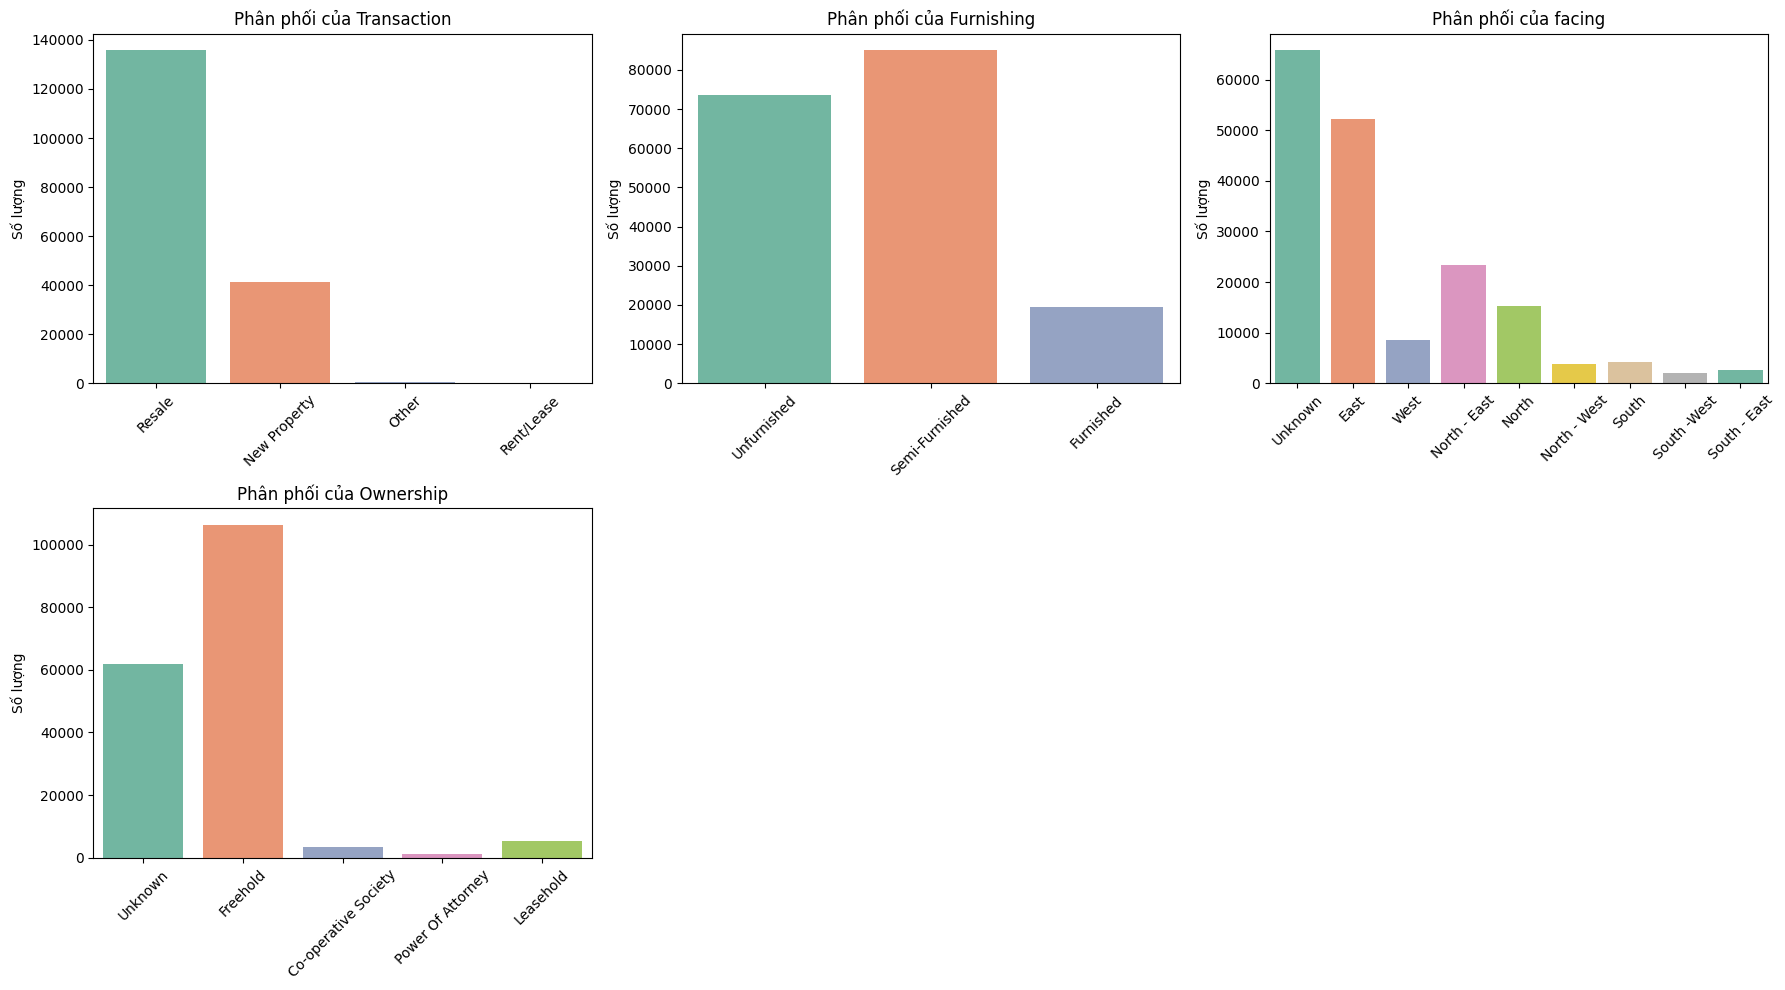

In [28]:
cat_cols = ['Transaction', 'Furnishing', 'facing', 'Ownership']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in data.columns:
        sns.countplot(data=data, x=col, ax=axes[i], palette='Set2')
        axes[i].set_title(f'Phân phối của {col}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel('Số lượng')
        axes[i].set_xlabel('')

# Xóa trục trống nếu có
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

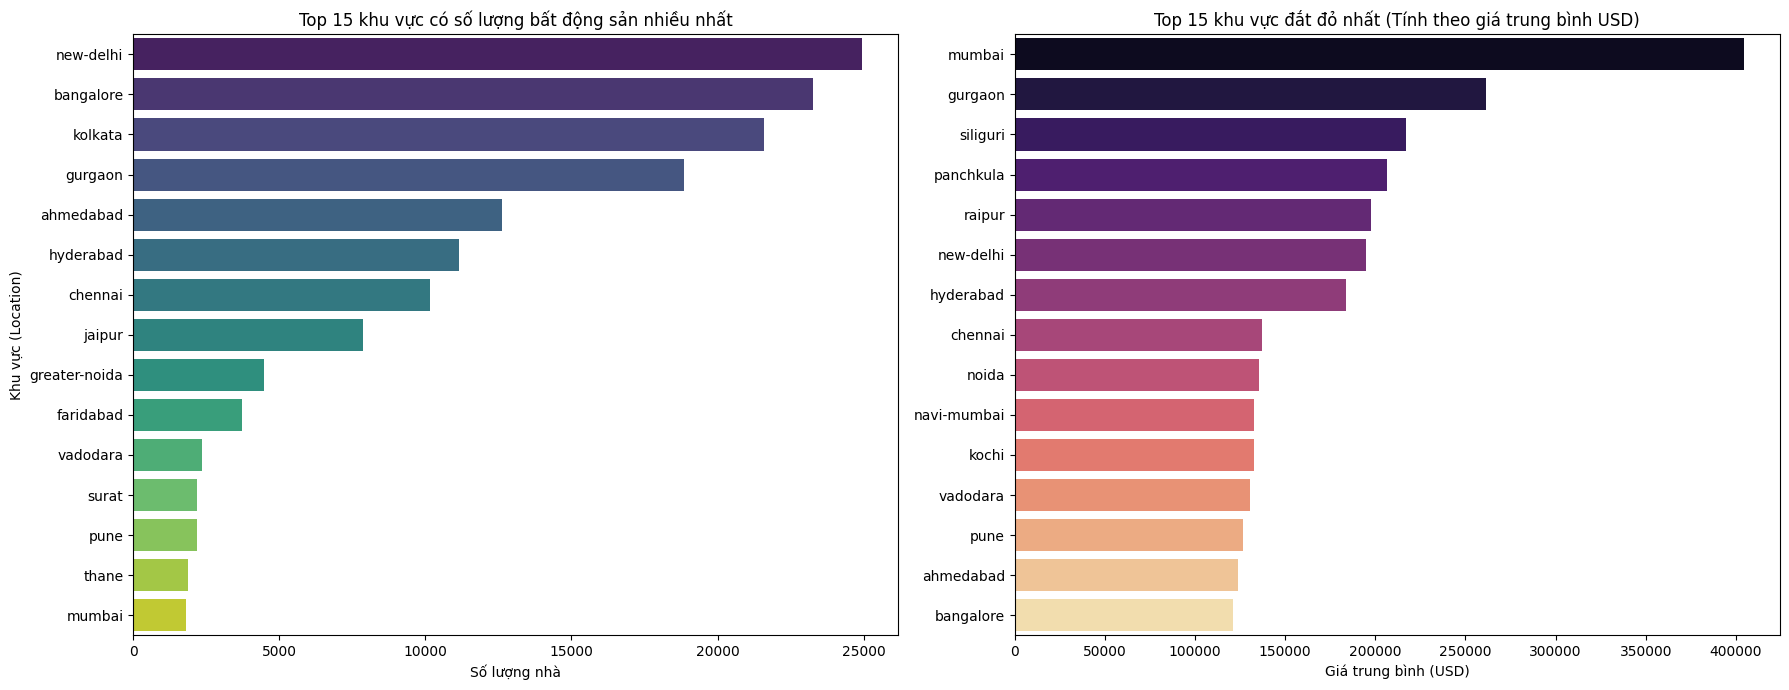

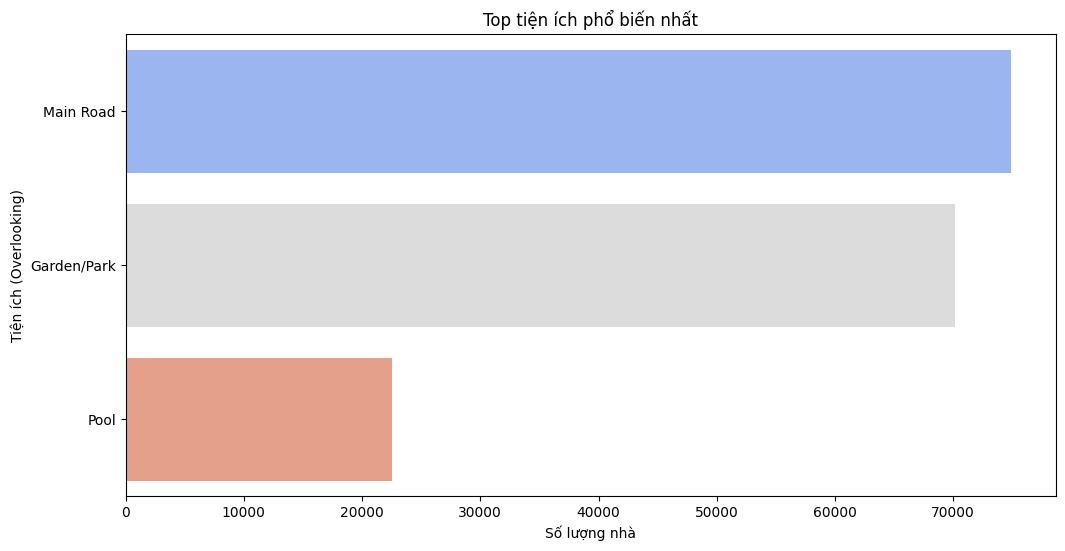

In [29]:

# Thống kê Top 15 location có nhiều nhà nhất
top_15_locations = data['location'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=top_15_locations.values, y=top_15_locations.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 khu vực có số lượng bất động sản nhiều nhất')
axes[0].set_xlabel('Số lượng nhà')
axes[0].set_ylabel('Khu vực (Location)')

# Top 15 location có giá nhà trung bình CAO NHẤT (Xét khu vực có >= 50 căn)
loc_counts = data['location'].value_counts()
valid_locs = loc_counts[loc_counts >= 50].index
avg_price_by_loc = data[data['location'].isin(valid_locs) & data['Price_total'].notna()]['Price_total'].groupby(data['location']).mean()
top_15_expensive = avg_price_by_loc.sort_values(ascending=False).head(15)

sns.barplot(x=top_15_expensive.values, y=top_15_expensive.index, ax=axes[1], palette='magma')
axes[1].set_title('Top 15 khu vực đắt đỏ nhất (Tính theo giá trung bình USD)')
axes[1].set_xlabel('Giá trung bình (USD)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Xem phân bố giá của Top 10 location phổ biến nhất bằng Boxplot
top_10_loc_names = top_15_locations.head(10).index
data_top_10 = data[data['location'].isin(top_10_loc_names)]



# Xử lý chuỗi overlooking để đếm chính xác từng loại tiện ích (tách bởi dấu phẩy)
all_views = data['overlooking'].dropna().astype(str).str.split(',').explode().str.strip()
view_counts = all_views[all_views != 'Unknown'].value_counts().head(3)

plt.figure(figsize=(12, 6))
sns.barplot(x=view_counts.values, y=view_counts.index, palette='coolwarm')
plt.title('Top tiện ích phổ biến nhất')
plt.xlabel('Số lượng nhà')
plt.ylabel('Tiện ích (Overlooking)')
plt.show()

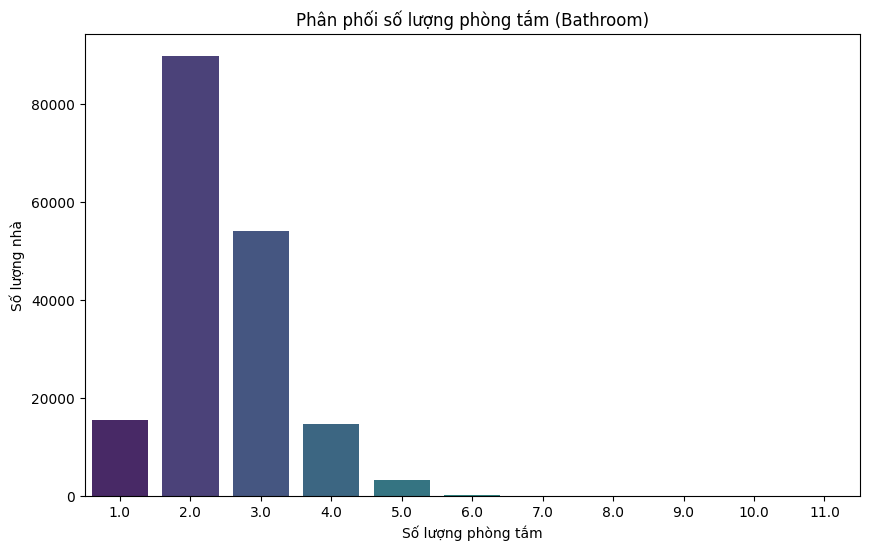

In [30]:

plt.figure(figsize=(10, 6))
sns.countplot(x='Bathroom', data=data, palette='viridis')
plt.title('Phân phối số lượng phòng tắm (Bathroom)')
plt.xlabel('Số lượng phòng tắm')
plt.ylabel('Số lượng nhà')
plt.show()

In [31]:
data['Bathroom'].describe()

count    177847.000000
mean          2.447570
std           0.857774
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          11.000000
Name: Bathroom, dtype: float64

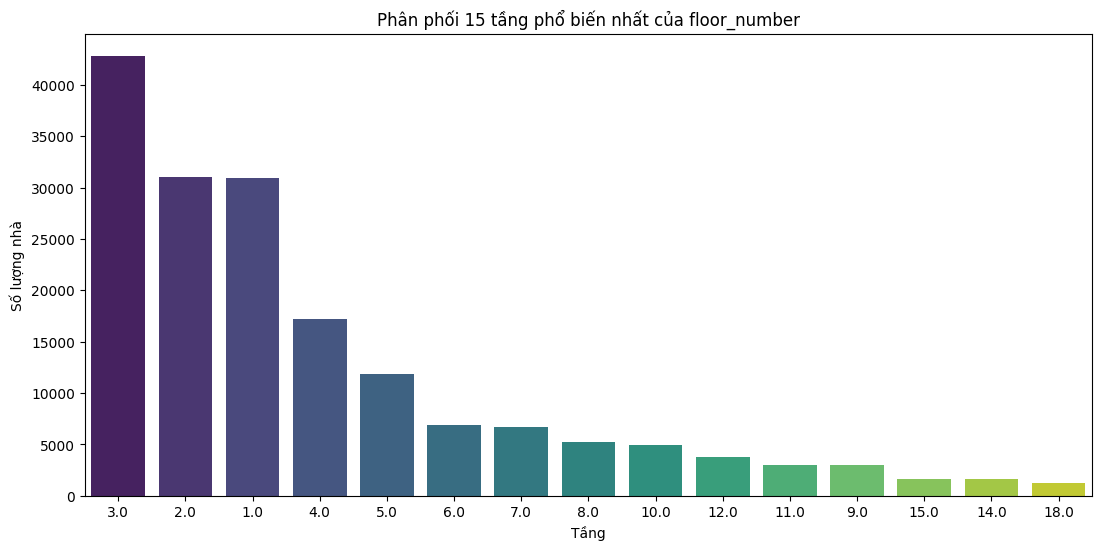

In [32]:
# Lấy 15 tầng phổ biến nhất để xem phân phối
top_floors = data['floor_number'].value_counts().nlargest(15).index
data_top_floors = data[data['floor_number'].isin(top_floors)]

plt.figure(figsize=(13, 6))
# Vẽ biểu đồ theo thứ tự phổ biến giảm dần
sns.countplot(x='floor_number', data=data_top_floors, order=top_floors, palette='viridis')
plt.title('Phân phối 15 tầng phổ biến nhất của floor_number')
plt.xlabel('Tầng')
plt.ylabel('Số lượng nhà')
plt.show()

In [33]:
data['floor_number'].describe()

count    177847.000000
mean          4.626465
std           4.492639
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max         200.000000
Name: floor_number, dtype: float64

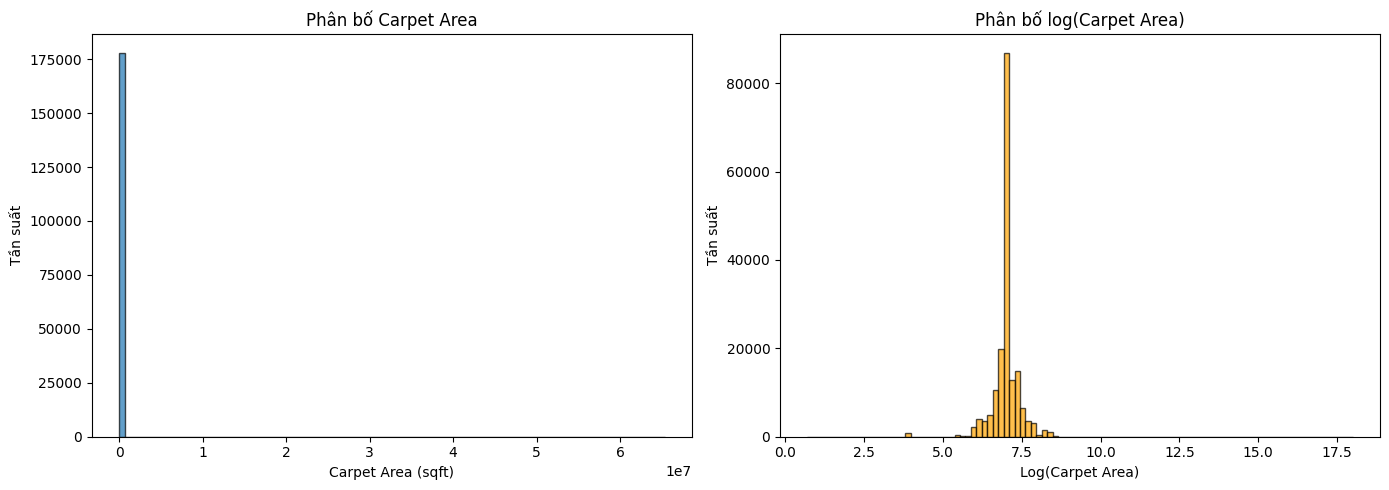

count    1.778470e+05
mean     1.805041e+03
std      1.859977e+05
min      1.000000e+00
25%      1.000000e+03
50%      1.064000e+03
75%      1.200000e+03
max      6.534000e+07
Name: Carpet Area, dtype: float64


In [34]:
# Phân bố Carpet Area (gốc và log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['Carpet Area'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title('Phân bố Carpet Area')
axes[0].set_xlabel('Carpet Area (sqft)')
axes[0].set_ylabel('Tần suất')

axes[1].hist(np.log1p(data['Carpet Area']), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Phân bố log(Carpet Area)')
axes[1].set_xlabel('Log(Carpet Area)')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

print(data['Carpet Area'].describe())

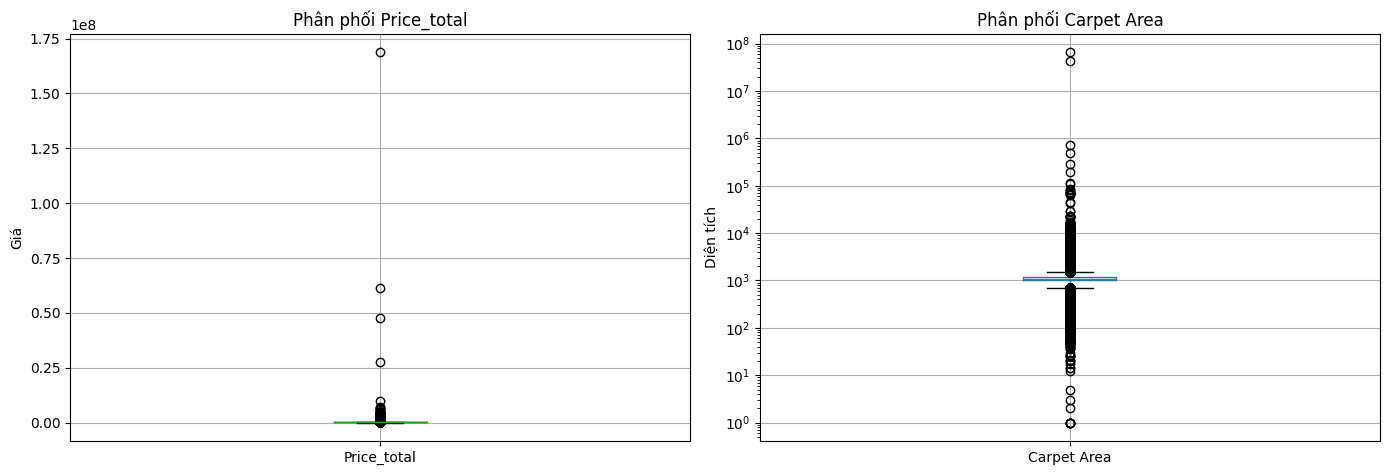

In [35]:
# Boxplot: giá và diện tích thảm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data.boxplot(column='Price_total', ax=axes[0])
axes[0].set_title('Phân phối Price_total')
axes[0].set_ylabel('Giá')
plt.yscale('log')
data.boxplot(column='Carpet Area', ax=axes[1])
axes[1].set_title('Phân phối Carpet Area')
axes[1].set_ylabel('Diện tích')
plt.yscale('log')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [36]:
# Loại bỏ ngoại lệ bằng percentile (1% - 99%)
Q1 = data['Price_total'].quantile(0.01)
Q3 = data['Price_total'].quantile(0.99)
print(f"Giữ lại giá trong khoảng: {Q1:,.0f} - {Q3:,.0f} USD")
data = data[(data['Price_total'] >= Q1) & (data['Price_total'] <= Q3)]

Q1_ca = data['Carpet Area'].quantile(0.01)
Q3_ca = data['Carpet Area'].quantile(0.99)
print(f"Giữ lại diện tích trong khoảng: {Q1_ca:,.0f} - {Q3_ca:,.0f} sqft")
data = data[(data['Carpet Area'] >= Q1_ca) & (data['Carpet Area'] <= Q3_ca)]

print(f"\nSố dòng sau khi loại ngoại lệ: {len(data)}")

Giữ lại giá trong khoảng: 19,277 - 843,373 USD
Giữ lại diện tích trong khoảng: 375 - 3,440 sqft

Số dòng sau khi loại ngoại lệ: 172016


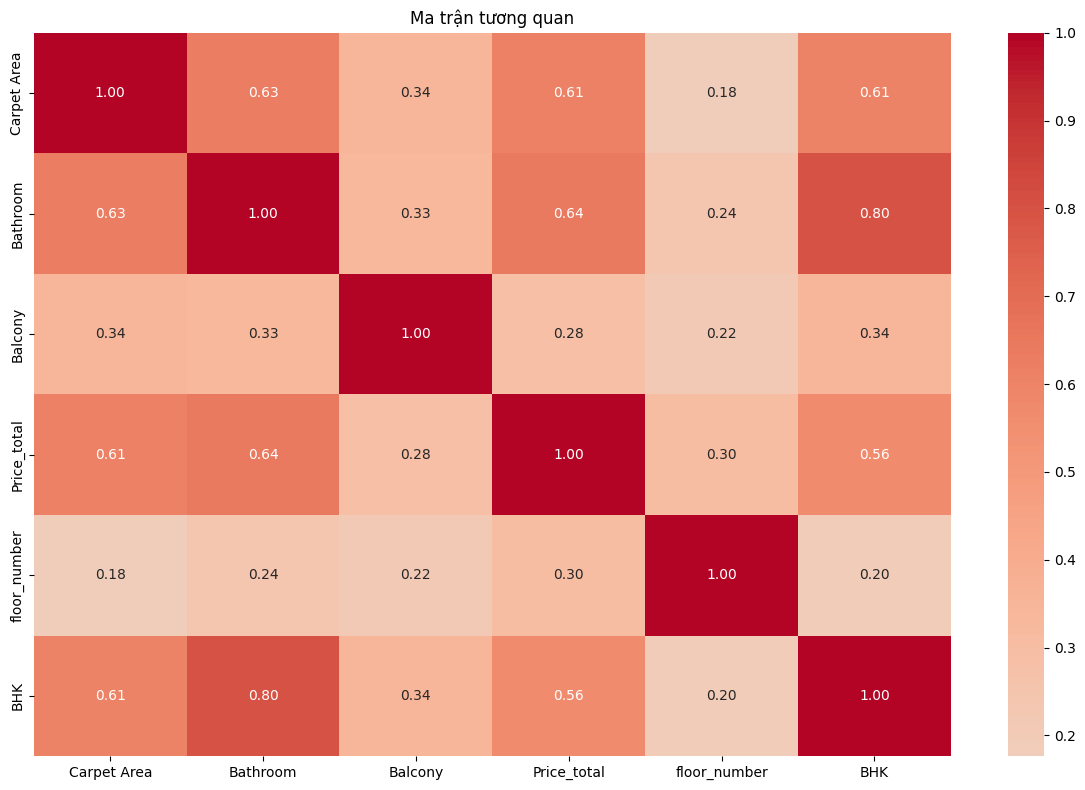

In [37]:
# Ma trận tương quan giữa các biến số
numeric_cols = data.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(12, 8))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0)
ax.set_title('Ma trận tương quan')
plt.tight_layout()
plt.show()

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172016 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   location      172016 non-null  object 
 1   Carpet Area   172016 non-null  float64
 2   Status        172016 non-null  object 
 3   Transaction   172016 non-null  object 
 4   Furnishing    172016 non-null  object 
 5   facing        172016 non-null  object 
 6   overlooking   172016 non-null  object 
 7   Bathroom      172016 non-null  float64
 8   Balcony       172016 non-null  float64
 9   Ownership     172016 non-null  object 
 10  Price_total   172016 non-null  float64
 11  floor_number  172016 non-null  float64
 12  BHK           172016 non-null  float64
dtypes: float64(6), object(7)
memory usage: 18.4+ MB


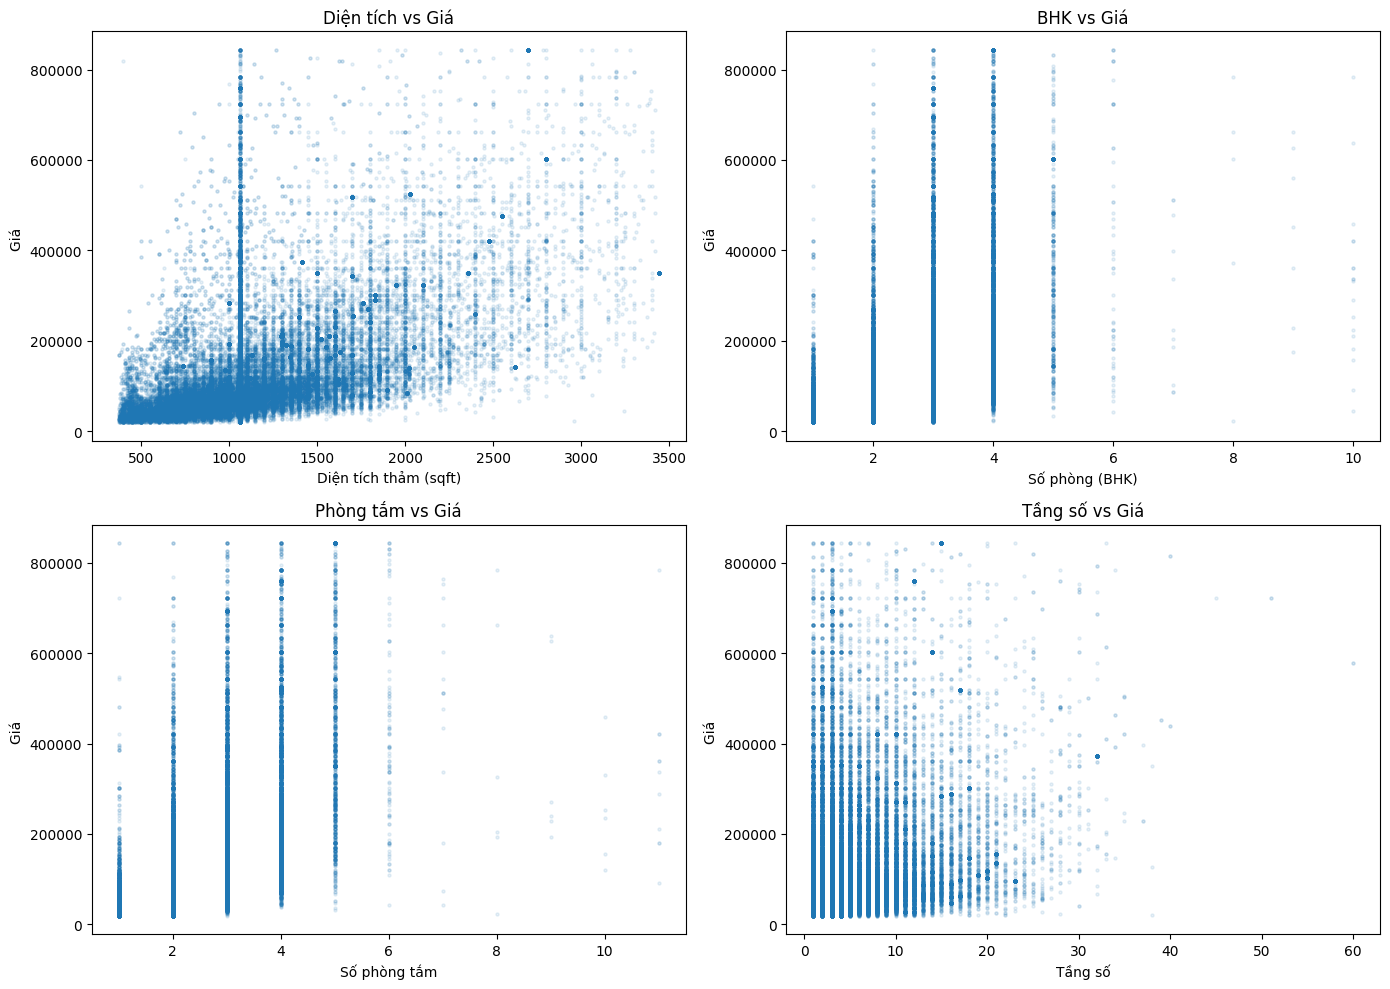

In [39]:
# Biểu đồ phân tán: các biến chính vs giá nhà
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(data['Carpet Area'], data['Price_total'], alpha=0.1, s=5)
axes[0, 0].set_xlabel('Diện tích thảm (sqft)')
axes[0, 0].set_ylabel('Giá ')
axes[0, 0].set_title('Diện tích vs Giá')

axes[0, 1].scatter(data['BHK'], data['Price_total'], alpha=0.1, s=5)
axes[0, 1].set_xlabel('Số phòng (BHK)')
axes[0, 1].set_ylabel('Giá ')
axes[0, 1].set_title('BHK vs Giá')

axes[1, 0].scatter(data['Bathroom'], data['Price_total'], alpha=0.1, s=5)
axes[1, 0].set_xlabel('Số phòng tắm')
axes[1, 0].set_ylabel('Giá ')
axes[1, 0].set_title('Phòng tắm vs Giá')

axes[1, 1].scatter(data['floor_number'], data['Price_total'], alpha=0.1, s=5)
axes[1, 1].set_xlabel('Tầng số')
axes[1, 1].set_ylabel('Giá ')
axes[1, 1].set_title('Tầng số vs Giá')

plt.tight_layout()
plt.show()

## Xử lý đặc trưng và mã hóa

In [40]:
# Mã hóa location bằng target encoding (trung bình giá theo thành phố)
location_mean = data.groupby('location')['Price_total'].mean()
data['location_encoded'] = data['location'].map(location_mean)

# Đơn giản hóa overlooking: đếm số tiện ích
data['overlooking_count'] = data['overlooking'].apply(
    lambda x: len(str(x).split(',')) if x != 'Unknown' else 0
)

# Tạo biến nhị phân cho tiện ích phổ biến
for item in ['Garden/Park', 'Main Road', 'Pool', 'Club']:
    col_name = f'overlooking_{item.replace("/", "_").replace(" ", "_")}'
    data[col_name] = data['overlooking'].str.contains(item, case=False, na=False).astype(int)

# One-hot encoding cho các biến phân loại ít danh mục
data = pd.get_dummies(data, columns=['Transaction', 'Furnishing', 'Status',
                                      'Ownership', 'facing'], drop_first=True)

# Xóa cột gốc không cần nữa
data = data.drop(columns=['location', 'overlooking'])

print(f"Shape sau mã hóa: {data.shape}")
data.head()

Shape sau mã hóa: (172016, 29)


,Carpet Area,Bathroom,Balcony,Price_total,floor_number,BHK,location_encoded,overlooking_count,overlooking_Garden_Park,overlooking_Main_Road,...,Ownership_Power Of Attorney,Ownership_Unknown,facing_North,facing_North - East,facing_North - West,facing_South,facing_South - East,facing_South -West,facing_Unknown,facing_West
0,500.0,1.0,2.0,50602.409639,10.0,1.0,118950.673916,0,0,0,...,False,True,False,False,False,False,False,False,True,False
1,473.0,2.0,2.0,118072.289157,3.0,2.0,118950.673916,1,1,0,...,False,False,False,False,False,False,False,False,False,False
2,779.0,2.0,2.0,168674.698795,10.0,2.0,118950.673916,1,1,0,...,False,False,False,False,False,False,False,False,False,False
3,530.0,1.0,1.0,30120.481928,1.0,1.0,118950.673916,0,0,0,...,False,True,False,False,False,False,False,False,True,False
4,635.0,2.0,2.0,192771.084337,20.0,2.0,118950.673916,2,1,1,...,False,False,False,False,False,False,False,False,False,True


In [41]:
# Log-transform biến mục tiêu (giá nhà lệch phải mạnh)
data['log_price'] = np.log1p(data['Price_total'])

data['area_per_bhk'] = data['Carpet Area'] / data['BHK'].clip(lower=1)
data['bath_per_bhk'] = data['Bathroom'] / data['BHK'].clip(lower=1)

print("Các đặc trưng tương tác mới:")
print(data[['area_per_bhk', 'bath_per_bhk']].describe())

Các đặc trưng tương tác mới:
        area_per_bhk   bath_per_bhk
count  172016.000000  172016.000000
mean      459.168629       0.950455
std       151.682661       0.187334
min       100.000000       0.100000
25%       354.666667       1.000000
50%       440.000000       1.000000
75%       532.000000       1.000000
max      3243.000000       4.000000


In [42]:
data[['area_per_bhk', 'bath_per_bhk']].describe()

,area_per_bhk,bath_per_bhk
count,172016.000000,172016.000000
mean,459.168629,0.950455
std,151.682661,0.187334
min,100.000000,0.100000
25%,354.666667,1.000000
50%,440.000000,1.000000
75%,532.000000,1.000000
max,3243.000000,4.000000


In [43]:
data.shape

(172016, 32)

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172016 entries, 0 to 187530
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Carpet Area                  172016 non-null  float64
 1   Bathroom                     172016 non-null  float64
 2   Balcony                      172016 non-null  float64
 3   Price_total                  172016 non-null  float64
 4   floor_number                 172016 non-null  float64
 5   BHK                          172016 non-null  float64
 6   location_encoded             172016 non-null  float64
 7   overlooking_count            172016 non-null  int64  
 8   overlooking_Garden_Park      172016 non-null  int64  
 9   overlooking_Main_Road        172016 non-null  int64  
 10  overlooking_Pool             172016 non-null  int64  
 11  overlooking_Club             172016 non-null  int64  
 12  Transaction_Other            172016 non-null  bool   
 13  Tran

## Xây dựng mô hình hồi quy tuyến tính

In [45]:
# Chuẩn bị dữ liệu cho mô hình
target = 'log_price'

drop_cols = ['Price_total', 'log_price']
feature_cols = [c for c in data.columns if c not in drop_cols]

X = data[feature_cols].copy()
y = data[target].copy()

# Xử lý inf/nan còn sót
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print(f"Số đặc trưng: {X.shape[1]}")
print(f"Số mẫu: {X.shape[0]}")
print(f"\nDanh sách đặc trưng ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  {i+1}. {col}")

# Chia tập train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTập train: {X_train.shape[0]} mẫu")
print(f"Tập test: {X_test.shape[0]} mẫu")

Số đặc trưng: 30
Số mẫu: 172016

Danh sách đặc trưng (30):
  1. Carpet Area
  2. Bathroom
  3. Balcony
  4. floor_number
  5. BHK
  6. location_encoded
  7. overlooking_count
  8. overlooking_Garden_Park
  9. overlooking_Main_Road
  10. overlooking_Pool
  11. overlooking_Club
  12. Transaction_Other
  13. Transaction_Rent/Lease
  14. Transaction_Resale
  15. Furnishing_Semi-Furnished
  16. Furnishing_Unfurnished
  17. Ownership_Freehold
  18. Ownership_Leasehold
  19. Ownership_Power Of Attorney
  20. Ownership_Unknown
  21. facing_North
  22. facing_North - East
  23. facing_North - West
  24. facing_South
  25. facing_South - East
  26. facing_South -West
  27. facing_Unknown
  28. facing_West
  29. area_per_bhk
  30. bath_per_bhk

Tập train: 137612 mẫu
Tập test: 34404 mẫu


In [46]:
# Chuẩn hóa đặc trưng
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình hồi quy tuyến tính
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Hoàn thành huấn luyện mô hình Linear Regression!")

Hoàn thành huấn luyện mô hình Linear Regression!


In [47]:
# Dự đoán trên tập test
y_pred_log = model.predict(X_test_scaled)

# Chuyển về giá gốc (undo log transform)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Loại bỏ dự đoán âm
y_pred = np.clip(y_pred, 0, None)

# Tính các chỉ số đánh giá
r2 = r2_score(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

# MAPE (loại bỏ giá trị 0 để tránh chia cho 0)
mask = y_actual > 0
mape = np.mean(np.abs((y_actual[mask] - y_pred[mask]) / y_actual[mask])) * 100

# R² trên log scale
r2_log = r2_score(y_test, y_pred_log)

print("=" * 55)
print("  KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH HỒI QUY TUYẾN TÍNH")
print("=" * 55)
print(f"  R² Score (log scale):          {r2_log:.4f}")
print(f"  R² Score (giá gốc):            {r2:.4f}")
print(f"  MAE (Mean Absolute Error):      {mae:,.0f} USD")
print(f"  RMSE (Root Mean Squared Error): {rmse:,.0f} USD")
print(f"  MAPE (Mean Abs % Error):        {mape:.2f}%")
print("=" * 55)

  KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH HỒI QUY TUYẾN TÍNH
  R² Score (log scale):          0.6431
  R² Score (giá gốc):            0.5369
  MAE (Mean Absolute Error):      46,166 USD
  RMSE (Root Mean Squared Error): 82,285 USD
  MAPE (Mean Abs % Error):        38.17%


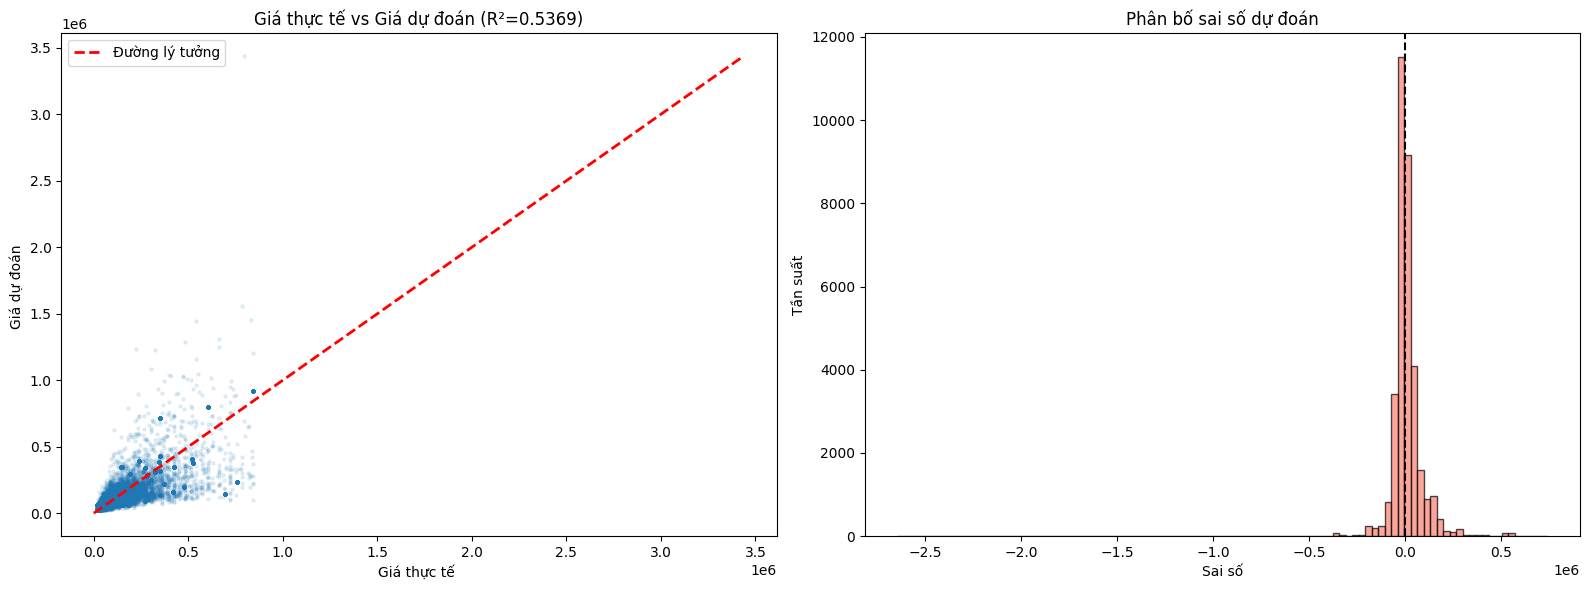

In [48]:
# Biểu đồ: Giá thực tế vs Giá dự đoán + Phân bố sai số
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Thực tế vs Dự đoán
axes[0].scatter(y_actual, y_pred, alpha=0.1, s=5)
max_val = max(y_actual.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Đường lý tưởng')
axes[0].set_xlabel('Giá thực tế ')
axes[0].set_ylabel('Giá dự đoán ')
axes[0].set_title(f'Giá thực tế vs Giá dự đoán (R²={r2:.4f})')
axes[0].legend()

# Phân bố sai số
residuals = y_actual - y_pred
axes[1].hist(residuals, bins=100, edgecolor='black', alpha=0.7, color='salmon')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel('Sai số')
axes[1].set_ylabel('Tần suất')
axes[1].set_title('Phân bố sai số dự đoán')

plt.tight_layout()
plt.show()

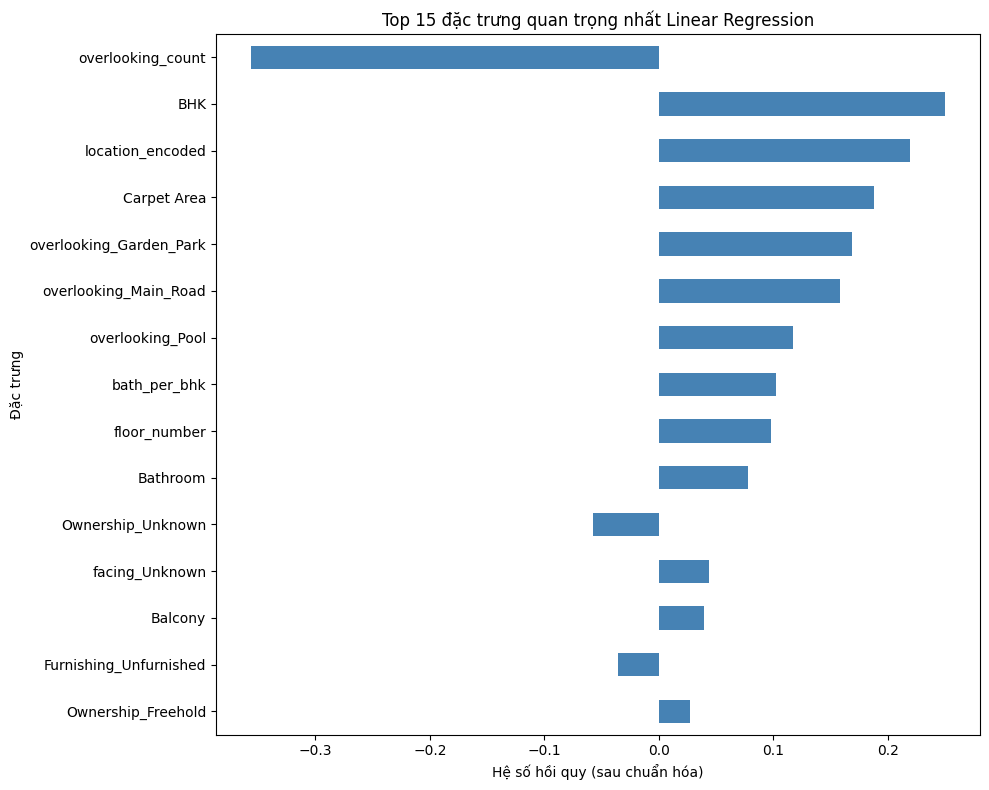

In [57]:
# Top 15 đặc trưng quan trọng nhất (theo hệ số hồi quy)
feature_importance = pd.DataFrame({
    'Đặc trưng': feature_cols,
    'Hệ số': model.coef_
})
feature_importance['Abs_hệ_số'] = feature_importance['Hệ số'].abs()
feature_importance = feature_importance.sort_values('Abs_hệ_số', ascending=True)

top_n = min(15, len(feature_importance))
fig, ax = plt.subplots(figsize=(10, 8))
feature_importance.tail(top_n).plot.barh(x='Đặc trưng', y='Hệ số', ax=ax, color='steelblue', legend=False)
ax.set_title(f'Top {top_n} đặc trưng quan trọng nhất Linear Regression')
ax.set_xlabel('Hệ số hồi quy (sau chuẩn hóa)')
plt.tight_layout()
plt.show()

R² trên tập train (log): 0.6424
R² trên tập test (log):  0.6431
Chênh lệch:              -0.0008

Mô hình khái quát hóa tốt.


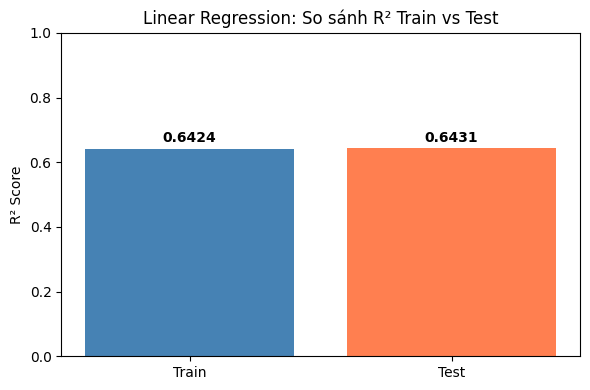

In [55]:
# Kiểm tra overfitting: so sánh R² train vs test
y_train_pred_log = model.predict(X_train_scaled)
r2_train = r2_score(y_train, y_train_pred_log)
r2_test = r2_score(y_test, y_pred_log)

print(f"R² trên tập train (log): {r2_train:.4f}")
print(f"R² trên tập test (log):  {r2_test:.4f}")
print(f"Chênh lệch:              {r2_train - r2_test:.4f}")

if r2_train - r2_test > 0.05:
    print("\nMô hình có dấu hiệu overfitting!")
else:
    print("\nMô hình khái quát hóa tốt.")

# Biểu đồ so sánh
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Train', 'Test'], [r2_train, r2_test], color=['steelblue', 'coral'])
ax.set_ylabel('R² Score')
ax.set_title('Linear Regression: So sánh R² Train vs Test')
ax.set_ylim(0, 1)
for bar, val in zip(bars, [r2_train, r2_test]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## So sánh với các thuật toán ML khác

In [51]:
# Huấn luyện Random Forest
print("Đang huấn luyện Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_pred_log = rf_model.predict(X_test_scaled)
rf_pred = np.clip(np.expm1(rf_pred_log), 0, None)

print("Đang huấn luyện Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
)
gb_model.fit(X_train_scaled, y_train)

gb_pred_log = gb_model.predict(X_test_scaled)
gb_pred = np.clip(np.expm1(gb_pred_log), 0, None)

print("Hoàn thành huấn luyện cả 2 mô hình!")

Đang huấn luyện Random Forest...
Đang huấn luyện Gradient Boosting...
Hoàn thành huấn luyện cả 2 mô hình!


=== RANDOM FOREST ===
R² trên tập train (log): 0.9369
R² trên tập test (log):  0.9107
Chênh lệch:              0.0262
Mô hình khái quát hóa tốt.

=== GRADIENT BOOSTING ===
R² trên tập train (log): 0.8952
R² trên tập test (log):  0.8888
Chênh lệch:              0.0063
Mô hình khái quát hóa tốt.


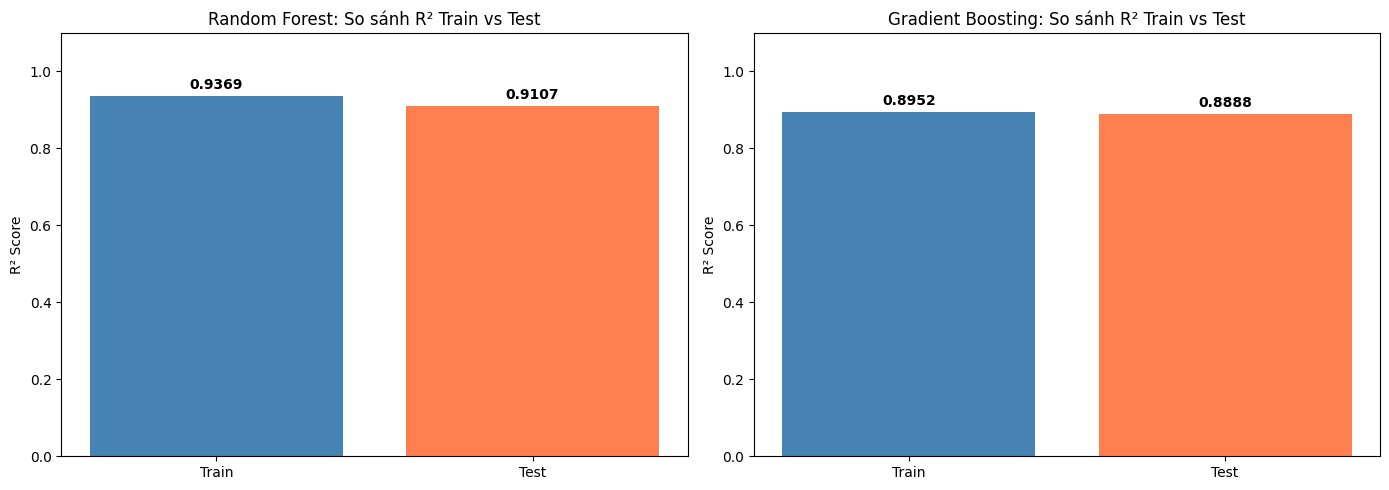

In [52]:
# Đánh giá Overfitting cho Random Forest và Gradient Boosting

# 1. Random Forest
rf_train_pred_log = rf_model.predict(X_train_scaled)
r2_train_rf = r2_score(y_train, rf_train_pred_log)
r2_test_rf = r2_score(y_test, rf_pred_log)

# 2. Gradient Boosting
gb_train_pred_log = gb_model.predict(X_train_scaled)
r2_train_gb = r2_score(y_train, gb_train_pred_log)
r2_test_gb = r2_score(y_test, gb_pred_log)

print("=== RANDOM FOREST ===")
print(f"R² trên tập train (log): {r2_train_rf:.4f}")
print(f"R² trên tập test (log):  {r2_test_rf:.4f}")
print(f"Chênh lệch:              {r2_train_rf - r2_test_rf:.4f}")
if r2_train_rf - r2_test_rf > 0.05:
    print("Mô hình có dấu hiệu overfitting!")
else:
    print("Mô hình khái quát hóa tốt.")

print("\n=== GRADIENT BOOSTING ===")
print(f"R² trên tập train (log): {r2_train_gb:.4f}")
print(f"R² trên tập test (log):  {r2_test_gb:.4f}")
print(f"Chênh lệch:              {r2_train_gb - r2_test_gb:.4f}")
if r2_train_gb - r2_test_gb > 0.05:
    print("Mô hình có dấu hiệu overfitting!")
else:
    print("Mô hình khái quát hóa tốt.")

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ RF
bars_rf = axes[0].bar(['Train', 'Test'], [r2_train_rf, r2_test_rf], color=['steelblue', 'coral'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('Random Forest: So sánh R² Train vs Test')
axes[0].set_ylim(0, 1.1)
for bar, val in zip(bars_rf, [r2_train_rf, r2_test_rf]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Biểu đồ GB
bars_gb = axes[1].bar(['Train', 'Test'], [r2_train_gb, r2_test_gb], color=['steelblue', 'coral'])
axes[1].set_ylabel('R² Score')
axes[1].set_title('Gradient Boosting: So sánh R² Train vs Test')
axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars_gb, [r2_train_gb, r2_test_gb]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


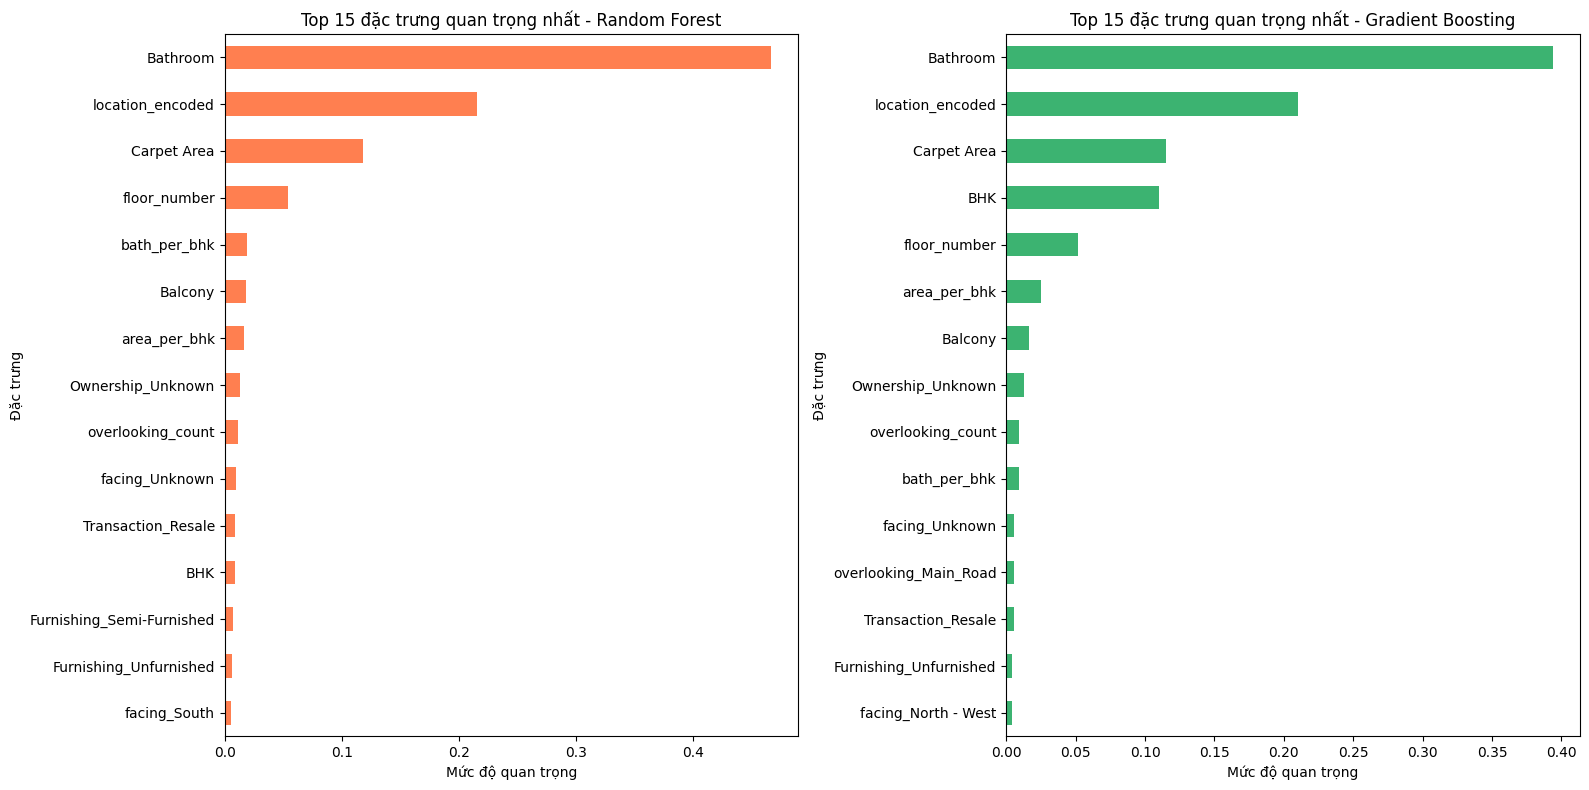

In [56]:
# Biểu đồ Top 15 Đặc trưng quan trọng nhất (Feature Importance) của mô hình Tree-based
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Random Forest
rf_importance = pd.DataFrame({
    'Đặc trưng': feature_cols,
    'Mức độ quan trọng': rf_model.feature_importances_
}).sort_values('Mức độ quan trọng', ascending=True)

rf_importance.tail(15).plot.barh(x='Đặc trưng', y='Mức độ quan trọng', ax=axes[0], color='coral', legend=False)
axes[0].set_title('Top 15 đặc trưng quan trọng nhất - Random Forest')
axes[0].set_xlabel('Mức độ quan trọng')

# 2. Gradient Boosting
gb_importance = pd.DataFrame({
    'Đặc trưng': feature_cols,
    'Mức độ quan trọng': gb_model.feature_importances_
}).sort_values('Mức độ quan trọng', ascending=True)

gb_importance.tail(15).plot.barh(x='Đặc trưng', y='Mức độ quan trọng', ax=axes[1], color='mediumseagreen', legend=False)
axes[1].set_title('Top 15 đặc trưng quan trọng nhất - Gradient Boosting')
axes[1].set_xlabel('Mức độ quan trọng')

plt.tight_layout()
plt.show()


In [53]:
# Bảng so sánh metrics 3 mô hình
def calc_metrics(y_true, y_pred, y_true_log, y_pred_log):
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {
        'R² (log)': r2_score(y_true_log, y_pred_log),
        'R² (giá gốc)': r2_score(y_true, y_pred),
        'MAE (Rupee)': mean_absolute_error(y_true, y_pred),
        'RMSE (Rupee)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': mape
    }

results = {
    'Linear Regression': calc_metrics(y_actual, y_pred, y_test, y_pred_log),
    'Random Forest': calc_metrics(y_actual, rf_pred, y_test, rf_pred_log),
    'Gradient Boosting': calc_metrics(y_actual, gb_pred, y_test, gb_pred_log),
}

comparison = pd.DataFrame(results).T
comparison['MAE (Rupee)'] = comparison['MAE (Rupee)'].apply(lambda x: f"{x:,.0f}")
comparison['RMSE (Rupee)'] = comparison['RMSE (Rupee)'].apply(lambda x: f"{x:,.0f}")
comparison['MAPE (%)'] = comparison['MAPE (%)'].apply(lambda x: f"{x:.2f}")
comparison['R² (log)'] = comparison['R² (log)'].apply(lambda x: f"{x:.4f}")
comparison['R² (giá gốc)'] = comparison['R² (giá gốc)'].apply(lambda x: f"{x:.4f}")

print("=" * 70)
print("         BẢNG SO SÁNH 3 MÔ HÌNH")
print("=" * 70)
comparison

         BẢNG SO SÁNH 3 MÔ HÌNH


,R² (log),R² (giá gốc),MAE (Rupee),RMSE (Rupee),MAPE (%)
Linear Regression,0.6431,0.5369,"46,166","82,285",38.17
Random Forest,0.9107,0.9119,"13,270","35,884",12.19
Gradient Boosting,0.8888,0.8734,"19,500","43,029",16.70


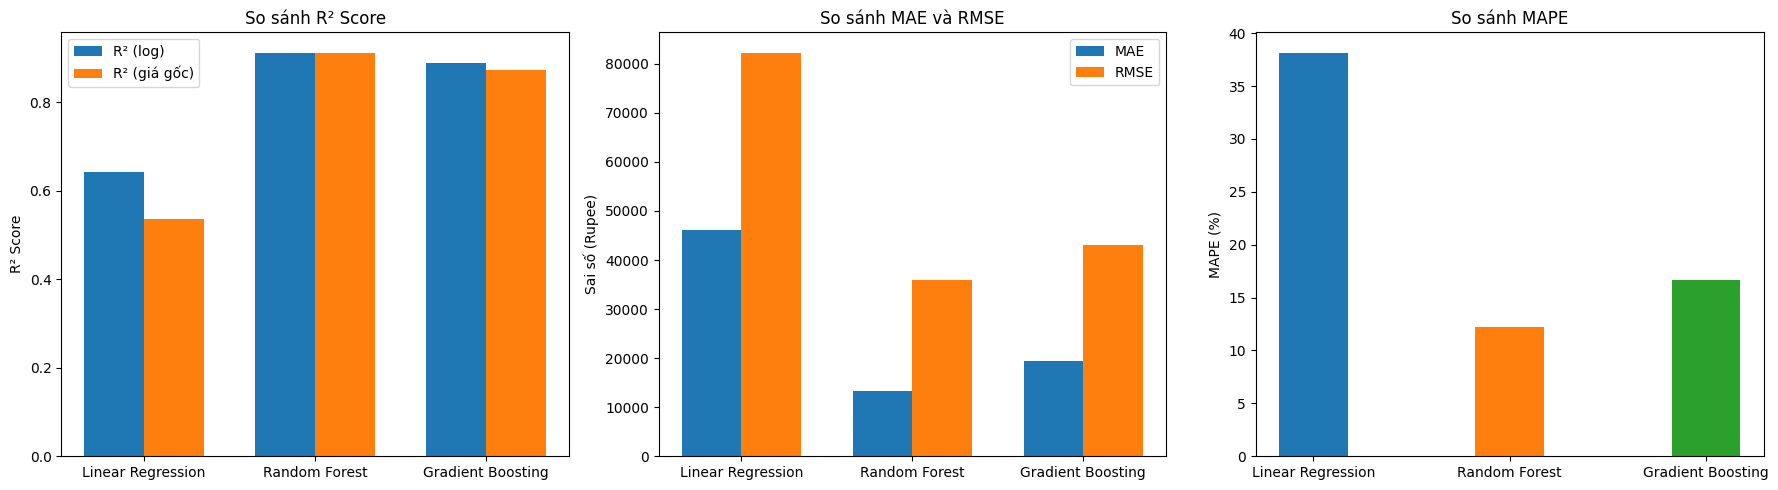

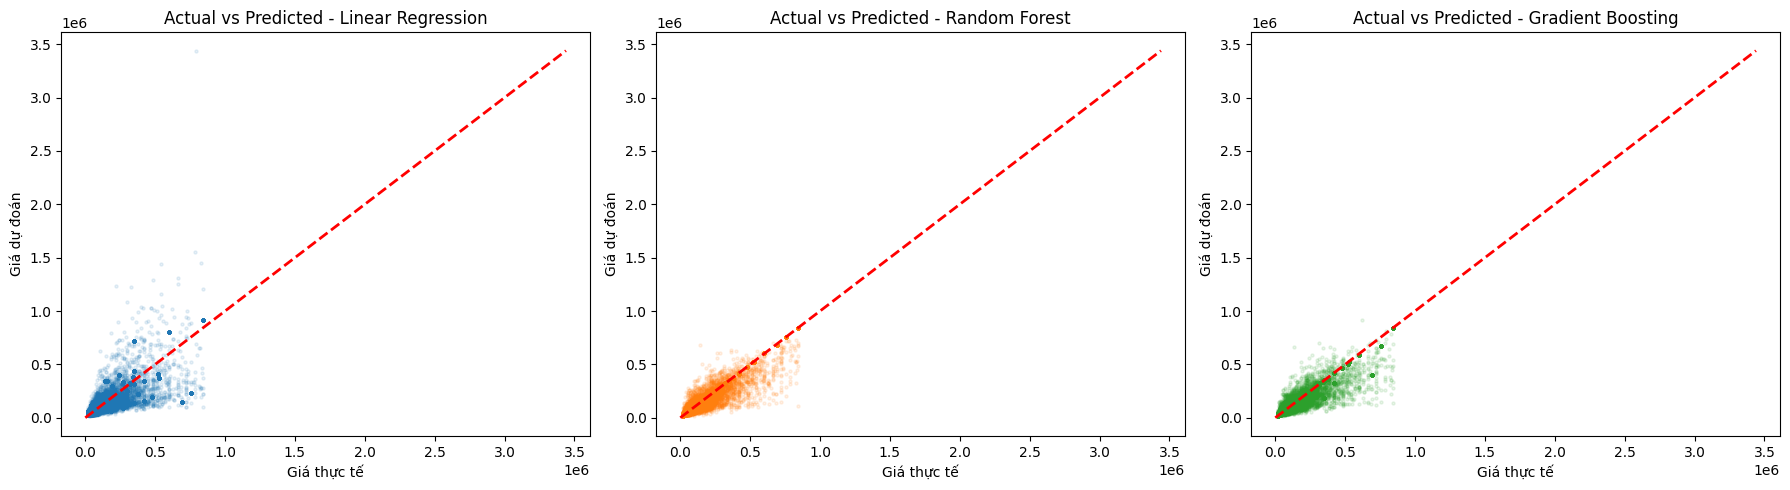

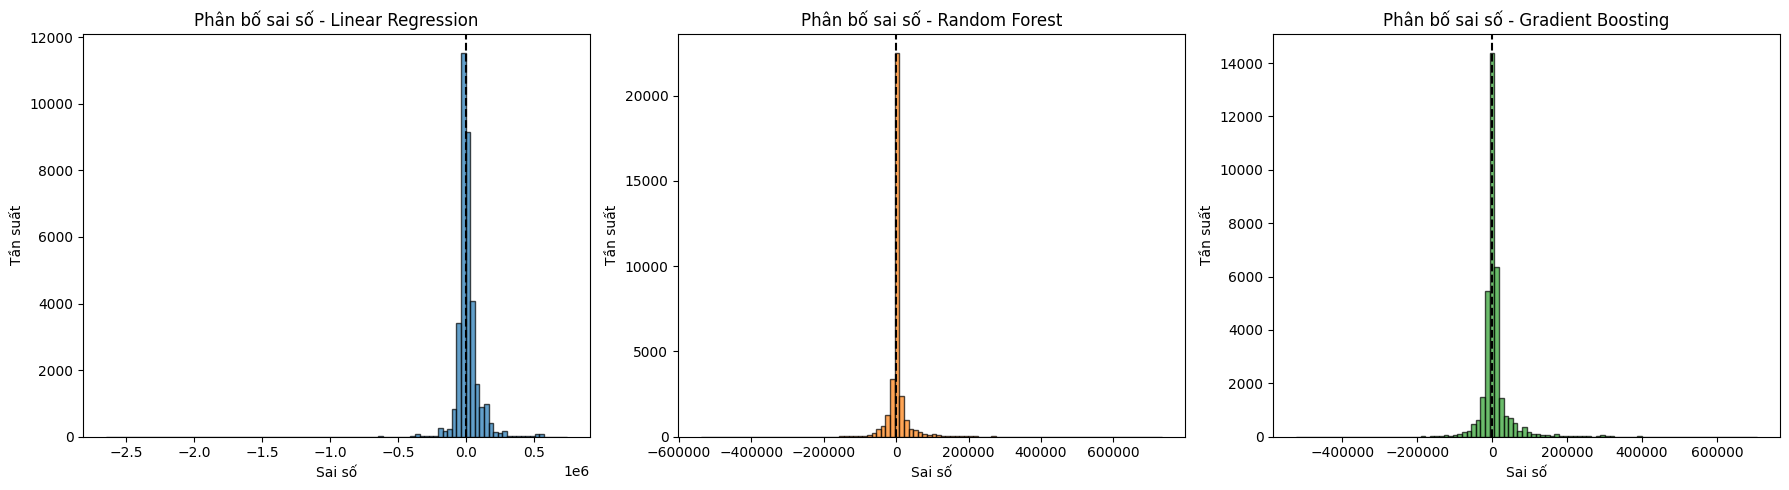

In [54]:


# 1. Đồ thị so sánh kết quả 3 mô hình
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
r2_log = [0.6431, 0.9107, 0.8888]
r2_actual = [0.5369, 0.9119, 0.8734]
mae = [46166, 13270, 19500]
rmse = [82285, 35884, 43029]
mape = [38.17, 12.19, 16.70]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ R² Score
x = np.arange(len(models))
width = 0.35
axes[0].bar(x - width/2, r2_log, width, label='R² (log)')
axes[0].bar(x + width/2, r2_actual, width, label='R² (giá gốc)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('R² Score')
axes[0].set_title('So sánh R² Score')
axes[0].legend()

# Biểu đồ MAE & RMSE
axes[1].bar(x - width/2, mae, width, label='MAE')
axes[1].bar(x + width/2, rmse, width, label='RMSE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Sai số (Rupee)')
axes[1].set_title('So sánh MAE và RMSE')
axes[1].legend()

# Biểu đồ MAPE
axes[2].bar(x, mape, width, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].set_ylabel('MAPE (%)')
axes[2].set_title('So sánh MAPE')

plt.tight_layout()
plt.show()

# 2. Biểu đồ Actual vs Predicted cho cả 3 mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
preds = [y_pred, rf_pred, gb_pred]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

max_val = max(y_actual.max(), max([p.max() for p in preds]))

for i, ax in enumerate(axes):
    ax.scatter(y_actual, preds[i], alpha=0.1, s=5, color=colors[i])
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    ax.set_xlabel('Giá thực tế')
    ax.set_ylabel('Giá dự đoán')
    ax.set_title(f'Actual vs Predicted - {models[i]}')

plt.tight_layout()
plt.show()

# 3. Biểu đồ Residuals cho cả 3 mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ax in enumerate(axes):
    residuals = y_actual - preds[i]
    ax.hist(residuals, bins=100, edgecolor='black', alpha=0.7, color=colors[i])
    ax.axvline(x=0, color='black', linestyle='--')
    ax.set_xlabel('Sai số')
    ax.set_ylabel('Tần suất')
    ax.set_title(f'Phân bố sai số - {models[i]}')

plt.tight_layout()
plt.show()
